# CPBL Unsupervised Feature Discovery (2023 + 2024)

This notebook pre-processes the **rebas.tw** raw CPBL OpenData for both
**2023** and **2024**, runs descriptive statistics and EDA, and then
discovers features via **unsupervised learning only**
(filter pruning · PCA · clustering · dim-reduction), cross-checking the
result against 王學長's earlier supervised-consensus top-10 features
(`run_per_hit, innings_pitched, H, scored_first, whip_like, hr_allowed,
hits_allowed, AB, middle_runs, late_runs`).

All methods come from the 10 files in `course-material/` (knowledge base
distilled separately). Cell convention: each code cell is preceded by a
markdown cell stating **【目標 What?】**, **【說明 How to implement?】**,
and **【解釋結果 Why? How to explain the result】**. Tables and figures stay
**inline by default**; the final cell exposes a `DOWNLOAD_ALL` switch to
export everything as a single zip.

Karpathy-Skills principles apply (Think Before Coding · Simplicity First ·
Surgical Changes · Goal-Driven).

## Stage 0 — Setup

### 0.1 — Imports and runtime settings

**【目標 What?】** Load the scientific Python stack, fix the RNG seed, and verify versions.

**【說明 How to implement?】** Standard `pandas / numpy / scikit-learn / matplotlib / seaborn / scipy` plus `hdbscan`, `umap-learn`, `plotly`, `shap`. `%pip install` quietly if any are missing.

**【解釋結果 Why? How to explain the result】** All imports should succeed and versions print. A `ModuleNotFoundError` here means the cell-0 `%pip install` line needs to run before re-running this cell.

In [1]:
import os, sys, json, math, warnings, shutil, subprocess, zipfile
from pathlib import Path
from collections import Counter, defaultdict

# Bootstrap missing wheels quietly
def _ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        __import__(name)
    except ImportError:
        import subprocess as _sp
        _sp.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                        "--root-user-action=ignore", pkg])

for _p, _i in [("hdbscan", "hdbscan"), ("umap-learn", "umap"),
               ("plotly", "plotly"), ("shap", "shap")]:
    _ensure(_p, _i)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score, silhouette_samples)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist
import hdbscan
import umap
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"
import shap

from IPython.display import display, Markdown, FileLink

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.figsize"] = (8, 5)

print("python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("hdbscan     :", getattr(hdbscan, "__version__", "unknown"))
print("umap-learn  :", getattr(umap, "__version__", "unknown"))
print("shap        :", getattr(shap, "__version__", "unknown"))

python      : 3.11.15
numpy       : 2.4.6
pandas      : 3.0.3
scikit-learn: 1.8.0
hdbscan     : unknown
umap-learn  : 0.5.12
shap        : 0.51.0


### 0.2 — Output handling — inline-only by default

**【目標 What?】** Set up `DOWNLOAD_ALL` flag, `ARTIFACTS` registry, and the `show_and_track` helper.

**【說明 How to implement?】** Plain Python list-of-dicts; figures/tables stay in memory and render inline. Flag stays `False` until you flip it in the final cell.

**【解釋結果 Why? How to explain the result】** Should print `DOWNLOAD_ALL = False` and the empty registry — nothing else.

In [2]:
DOWNLOAD_ALL = False           # flip to True in the final cell to export
ARTIFACTS: list[dict] = []      # each: {"name": str, "kind": str, "payload": obj}

def show_and_track(obj, name: str, kind: str = "figure"):
    '''Render inline AND register for optional later export.'''
    ARTIFACTS.append({"name": name, "kind": kind, "payload": obj})
    return obj

print(f"DOWNLOAD_ALL = {DOWNLOAD_ALL}")
print(f"ARTIFACTS registry initialised (currently {len(ARTIFACTS)} entries)")

DOWNLOAD_ALL = False
ARTIFACTS registry initialised (currently 0 entries)


### 0.3 — Success criteria

**【目標 What?】** Print the per-stage success checklist before any analysis runs.

**【說明 How to implement?】** Static markdown table via `display(Markdown(...))`.

**【解釋結果 Why? How to explain the result】** Re-read this whenever a stage produces something unexpected.

In [3]:
display(Markdown('''
| Stage | Success criterion |
|---|---|
| 1 Preprocessing | ≥ 600 team-game rows across 2023+2024; <5 % missing on key features |
| 2 Desc stats | Pearson r AND Spearman ρ vs `win` and `run_diff` printed for all features |
| 3 EDA | ≥ 10 figures rendered (one per planned chart) |
| 4 Unsupervised | Chosen algo has silhouette ≥ 0.25 AND bootstrap-Jaccard ≥ 0.75 |
| 4 Corroboration | ≥ 6 of Wang's 10 features in top-\|loading\| of PC1+PC2 |
| 5 Synthesis | Overlap table + new candidate features printed |
| 6 Export | DOWNLOAD_ALL=False ⇒ no files written; True ⇒ zip + FileLink |
'''))


| Stage | Success criterion |
|---|---|
| 1 Preprocessing | ≥ 600 team-game rows across 2023+2024; <5 % missing on key features |
| 2 Desc stats | Pearson r AND Spearman ρ vs `win` and `run_diff` printed for all features |
| 3 EDA | ≥ 10 figures rendered (one per planned chart) |
| 4 Unsupervised | Chosen algo has silhouette ≥ 0.25 AND bootstrap-Jaccard ≥ 0.75 |
| 4 Corroboration | ≥ 6 of Wang's 10 features in top-\|loading\| of PC1+PC2 |
| 5 Synthesis | Overlap table + new candidate features printed |
| 6 Export | DOWNLOAD_ALL=False ⇒ no files written; True ⇒ zip + FileLink |


## Stage 1 — Preprocessing

*KB ← `topic07_data` + Wang's `clean_games.py` and `share_analyze/01_build_team_game_features.R`*

Goal: load both 2023 and 2024 raw OpenData JSON, build team-game-level rows (1 game → 2 rows), and derive the same features Wang used so cross-comparison is meaningful.

### 1.1 — Load 2023 raw OpenData

**【目標 What?】** Read all four 2023 release directories into one list of game dicts.

**【說明 How to implement?】** Iterate every `*.json` in each release dir; if a file is a JSON list, extend; if a dict, append. Wang's per-game files and the consolidated file are both loaded — duplicates are removed later by `(date, stadium, teams, scores)`.

**【解釋結果 Why? How to explain the result】** Each release dir reports its game count; total 2023 raw records prints. Reg-season is 300 games; postseason adds a handful — expect a four-digit raw count before dedup.

In [4]:
DATA_ROOT = Path("/home/user/data_science_final_project/data/raw")
DIRS_2023 = [
    DATA_ROOT / "CPBL-2023-G1-G150-OpenData",
    DATA_ROOT / "CPBL-2023-G151-G300-OpenData",
    DATA_ROOT / "CPBL-2023-Challenge-OpenData",
    DATA_ROOT / "CPBL-2023-TaiwanSeries-OpenData",
]

def load_games_from_dir(d: Path):
    games = []
    for p in sorted(d.glob("*.json")):
        try:
            with open(p, encoding="utf-8") as f:
                data = json.load(f)
        except json.JSONDecodeError as e:
            print(f"  skip {p.name}: {e}")
            continue
        if isinstance(data, list):
            games.extend(data)
        else:
            games.append(data)
    return games

raw_2023 = []
for d in DIRS_2023:
    chunk = load_games_from_dir(d)
    print(f"{d.name:42s} : {len(chunk):4d} records loaded")
    raw_2023.extend(chunk)

print(f"\nTotal 2023 raw records (pre-dedup): {len(raw_2023)}")

CPBL-2023-G1-G150-OpenData                 :  300 records loaded


CPBL-2023-G151-G300-OpenData               :  300 records loaded
CPBL-2023-Challenge-OpenData               :    6 records loaded
CPBL-2023-TaiwanSeries-OpenData            :   14 records loaded

Total 2023 raw records (pre-dedup): 620


### 1.2 — Load 2024 raw OpenData via `git show`

**【目標 What?】** Fetch the consolidated 2024 OpenData from Wang's `analyze_wang` branch without checking out.

**【說明 How to implement?】** `git show origin/analyze_wang:data/raw/CPBL-2024-OpenData/CPBL-2024-OpenData.json` from `/home/user/data_science`. Output is the JSON bytes — parse with `json.loads`.

**【解釋結果 Why? How to explain the result】** Should produce ~360 game records (full 2024 regular season + playoffs). If 0, the branch isn't fetched: run `git fetch origin analyze_wang` first.

In [5]:
WANG_REPO = "/home/user/data_science"
WANG_PATH = "data/raw/CPBL-2024-OpenData/CPBL-2024-OpenData.json"

proc = subprocess.run(
    ["git", "-C", WANG_REPO, "show", f"origin/analyze_wang:{WANG_PATH}"],
    capture_output=True, text=True, check=True,
)
raw_2024 = json.loads(proc.stdout)
print(f"2024 raw records: {len(raw_2024)}")

2024 raw records: 360


### 1.3 — Combine and tag seasons; basic dedup

**【目標 What?】** Concatenate 2023 and 2024 raw records into one list and tag each with a `season_tag`.

**【說明 How to implement?】** Add a `season_tag` field (`'2023'` / `'2024'`) to every dict so downstream steps can split.

**【解釋結果 Why? How to explain the result】** Print combined raw count and per-season counts. Expect 2023 ≈ 300 reg+post; 2024 ≈ 360 reg+post.

In [6]:
for g in raw_2023:
    g["season_tag"] = "2023"
for g in raw_2024:
    g["season_tag"] = "2024"

raw_all_raw = raw_2023 + raw_2024
seen = set()
raw_all = []
for g in raw_all_raw:
    key = (g.get("seasonId"), g.get("seq"), g.get("date"),
           g.get("stadium"), g.get("awayTeam"), g.get("homeTeam"))
    if key in seen:
        continue
    seen.add(key)
    raw_all.append(g)
print(f"Combined raw records: {len(raw_all_raw)} pre-dedup → {len(raw_all)} unique games")
print(pd.Series([g['season_tag'] for g in raw_all]).value_counts().rename('count').to_string())

Combined raw records: 980 pre-dedup → 670 unique games
2024    360
2023    310


### 1.4 — Build team-game base rows (Wang port)

**【目標 What?】** 1 game → 2 rows (away + home). Carry season, season_tag, date, stadium, teams, runs, run_diff, win.

**【說明 How to implement?】** Port of Wang's `build_team_game_base` R function. Use `sum_scores` for inning arrays (non-numeric tokens skipped).

**【解釋結果 Why? How to explain the result】** Result `team_game_base` shape ≈ (1300+, ~12). One row per team per game; both rows of a game share `game_id`.

In [7]:
def sum_scores(scores):
    '''Sum inning-by-inning scores into a total integer (skip non-numeric tokens).'''
    if not scores:
        return 0
    total = 0
    for s in scores:
        s_str = str(s).strip()
        if s_str.lstrip("-").isdigit():
            total += int(s_str)
    return total

def build_team_game_base(raw_games):
    rows = []
    for g in raw_games:
        away_runs = sum_scores(g.get("awayScores", []))
        home_runs = sum_scores(g.get("homeScores", []))
        game_id = f"{g.get('seasonId', '?')}-{g.get('seq', '?')}"
        common = dict(game_id=game_id,
                      season=g.get("season"),
                      season_tag=g.get("season_tag"),
                      seq=g.get("seq"),
                      date=g.get("date"),
                      stadium=g.get("stadium"))
        rows.append({**common,
                     "team": g.get("awayTeam"), "opponent": g.get("homeTeam"),
                     "is_home": False,
                     "runs_scored": away_runs, "runs_allowed": home_runs,
                     "run_diff": away_runs - home_runs,
                     "win": int(away_runs > home_runs)})
        rows.append({**common,
                     "team": g.get("homeTeam"), "opponent": g.get("awayTeam"),
                     "is_home": True,
                     "runs_scored": home_runs, "runs_allowed": away_runs,
                     "run_diff": home_runs - away_runs,
                     "win": int(home_runs > away_runs)})
    return pd.DataFrame(rows)

team_game_base = build_team_game_base(raw_all)

# Dedup on the natural key — same (date, stadium, team, opponent, runs) ⇒ same row
before = len(team_game_base)
team_game_base = team_game_base.drop_duplicates(
    subset=["date", "stadium", "team", "opponent", "runs_scored", "runs_allowed"]
).reset_index(drop=True)
print(f"team_game_base: {before} → {len(team_game_base)} rows after dedup")
team_game_base.head()

team_game_base: 1340 → 1340 rows after dedup


,game_id,season,season_tag,seq,date,stadium,team,opponent,is_home,runs_scored,runs_allowed,run_diff,win
0,CPBL-2023-sk-1,中職2023年,2023,1,2023-04-01 17:21,臺中市洲際棒球場,樂天桃猿,中信兄弟,False,4,1,3,1
1,CPBL-2023-sk-1,中職2023年,2023,1,2023-04-01 17:21,臺中市洲際棒球場,中信兄弟,樂天桃猿,True,1,4,-3,0
2,CPBL-2023-sk-10,中職2023年,2023,10,2023-04-07 18:36,臺北市立天母棒球場,中信兄弟,味全龍,False,4,6,-2,0
3,CPBL-2023-sk-10,中職2023年,2023,10,2023-04-07 18:36,臺北市立天母棒球場,味全龍,中信兄弟,True,6,4,2,1
4,CPBL-2023-sk-100,中職2023年,2023,100,2023-05-31 18:35,臺南市立棒球場,富邦悍將,統一7-ELEVEn獅,False,10,6,4,1


### 1.5 — Add game-flow features (inning-level)

**【目標 What?】** Add `early_runs / middle_runs / late_runs / scored_first / led_after_3 / led_after_6`.

**【說明 How to implement?】** Port of Wang's `add_game_flow_features`. For each game we walk inning arrays, compute cumulative scores at innings 3 and 6, detect first-scoring inning. Merge back on (game_id, team).

**【解釋結果 Why? How to explain the result】** Expect every team-game row to have non-null `early/middle/late_runs` (sum equals `runs_scored`). `scored_first` should be roughly balanced; `led_after_3` and `led_after_6` are strongly tied to `win`.

In [8]:
def add_game_flow_features(team_game_df, raw_games):
    flow = []
    for g in raw_games:
        away_scores = [int(s) for s in g.get("awayScores", []) if str(s).lstrip("-").isdigit()]
        home_scores = [int(s) for s in g.get("homeScores", []) if str(s).lstrip("-").isdigit()]
        game_id = f"{g.get('seasonId', '?')}-{g.get('seq', '?')}"

        def cum(arr, idx):
            arr = arr or [0]
            return sum(arr[:idx]) if len(arr) >= idx else sum(arr)
        a3, h3 = cum(away_scores, 3), cum(home_scores, 3)
        a6, h6 = cum(away_scores, 6), cum(home_scores, 6)

        first_a = next((i for i, s in enumerate(away_scores) if s > 0), None)
        first_h = next((i for i, s in enumerate(home_scores) if s > 0), None)
        away_first = first_a is not None and (first_h is None or first_a < first_h)
        home_first = first_h is not None and (first_a is None or first_h < first_a)

        flow.append(dict(game_id=game_id, team=g.get("awayTeam"),
                         early_runs=sum(away_scores[:3]),
                         middle_runs=sum(away_scores[3:6]),
                         late_runs=sum(away_scores[6:9]),
                         scored_first=int(away_first),
                         led_after_3=int(a3 > h3),
                         led_after_6=int(a6 > h6)))
        flow.append(dict(game_id=game_id, team=g.get("homeTeam"),
                         early_runs=sum(home_scores[:3]),
                         middle_runs=sum(home_scores[3:6]),
                         late_runs=sum(home_scores[6:9]),
                         scored_first=int(home_first),
                         led_after_3=int(h3 > a3),
                         led_after_6=int(h6 > a6)))
    return team_game_df.merge(pd.DataFrame(flow),
                              on=["game_id", "team"], how="left")

team_game = add_game_flow_features(team_game_base, raw_all)
print(team_game[["early_runs","middle_runs","late_runs","scored_first",
                 "led_after_3","led_after_6"]].describe().T.round(2))

               count  mean   std  min  25%  50%  75%   max
early_runs    1340.0  1.34  1.71  0.0  0.0  1.0  2.0  11.0
middle_runs   1340.0  1.46  1.82  0.0  0.0  1.0  2.0  11.0
late_runs     1340.0  1.29  1.69  0.0  0.0  1.0  2.0  11.0
scored_first  1340.0  0.44  0.50  0.0  0.0  0.0  1.0   1.0
led_after_3   1340.0  0.37  0.48  0.0  0.0  0.0  1.0   1.0
led_after_6   1340.0  0.43  0.50  0.0  0.0  0.0  1.0   1.0


### 1.6 — Add offense features (batterBox aggregation)

**【目標 What?】** Sum AB / H / BB / SO / 2B / 3B / HR across the team's batters; derive `extra_base_hits`, `power_score`, `run_per_hit`, `offense_pressure_score`.

**【說明 How to implement?】** Port of Wang's `add_offense_features`. Uses the `awayBatterBox` / `homeBatterBox` arrays in the raw game dict.

**【解釋結果 Why? How to explain the result】** Expect H/AB roughly 0.20–0.35 in distribution; `run_per_hit` mostly 0–1.5 (Wang's top-1 feature). If a column is all zero, the raw arrays may be missing for some games.

In [9]:
def _sum_box(box, stat):
    if not box:
        return 0
    return sum(int(b.get(stat) or 0) for b in box)

def add_offense_features(team_game_df, raw_games):
    rows = []
    for g in raw_games:
        game_id = f"{g.get('seasonId', '?')}-{g.get('seq', '?')}"
        for side in ("away", "home"):
            box = g.get(f"{side}BatterBox", []) or []
            team = g.get(f"{side}Team")
            ab = _sum_box(box, "AB")
            h = _sum_box(box, "H")
            bb = _sum_box(box, "BB")
            so = _sum_box(box, "SO")
            d2 = _sum_box(box, "2B")
            d3 = _sum_box(box, "3B")
            hr = _sum_box(box, "HR")
            runs = sum_scores(g.get(f"{side}Scores", []))
            xbh = d2 + d3 + hr
            power = d2 + 2*d3 + 3*hr
            rph = runs / h if h > 0 else 0.0
            ops_pres = runs + bb + xbh - 0.5*so
            rows.append(dict(game_id=game_id, team=team,
                             AB=ab, H=h, BB=bb, SO=so,
                             double=d2, triple=d3, HR=hr,
                             extra_base_hits=xbh,
                             power_score=power,
                             run_per_hit=rph,
                             offense_pressure_score=ops_pres))
    return team_game_df.merge(pd.DataFrame(rows),
                              on=["game_id", "team"], how="left")

team_game = add_offense_features(team_game, raw_all)
print(team_game[["AB","H","BB","SO","HR","extra_base_hits",
                 "power_score","run_per_hit","offense_pressure_score"]]
      .describe().T.round(2))

                         count   mean   std   min    25%    50%    75%   max
AB                      1340.0  33.79  3.83  20.0  31.00  33.00  36.00  52.0
H                       1340.0   8.84  3.44   0.0   6.00   8.00  11.00  21.0
BB                      1340.0   3.06  1.94   0.0   2.00   3.00   4.00  11.0
SO                      1340.0   6.53  2.75   0.0   5.00   6.00   8.00  17.0
HR                      1340.0   0.51  0.75   0.0   0.00   0.00   1.00   5.0
extra_base_hits         1340.0   2.13  1.60   0.0   1.00   2.00   3.00   9.0
power_score             1340.0   3.34  2.81   0.0   1.00   3.00   5.00  17.0
run_per_hit             1340.0   0.44  0.26   0.0   0.25   0.43   0.62   2.0
offense_pressure_score  1340.0   6.09  5.57  -5.5   2.00   5.50   9.50  31.0


### 1.7 — Add defense / pitching features (pitcherBox aggregation)

**【目標 What?】** Sum IPOuts / H / BB / HR / SO / R for the team's pitchers; derive `innings_pitched`, `whip_like`, `strikeout_walk_ratio`, `run_prevention_score`.

**【說明 How to implement?】** Port of Wang's `add_defense_pitching_features`. `innings_pitched = IPOuts / 3` (IPOuts is already the integer-outs notation in rebas — the baseball `5.2` gotcha doesn't apply here).

**【解釋結果 Why? How to explain the result】** `innings_pitched` should be ~9 for most games; `whip_like` typically 1.0–1.6 league-wide. `NaN` in `whip_like` flags a game with 0 outs recorded (extremely rare).

In [10]:
def add_defense_pitching_features(team_game_df, raw_games):
    rows = []
    for g in raw_games:
        game_id = f"{g.get('seasonId', '?')}-{g.get('seq', '?')}"
        for side in ("away", "home"):
            box = g.get(f"{side}PitcherBox", []) or []
            team = g.get(f"{side}Team")
            outs = _sum_box(box, "IPOuts")
            h_a = _sum_box(box, "H")
            bb_a = _sum_box(box, "BB")
            hr_a = _sum_box(box, "HR")
            so_p = _sum_box(box, "SO")
            r_a = _sum_box(box, "R")
            ip = outs / 3 if outs > 0 else 0.0
            whip = (h_a + bb_a) / ip if ip > 0 else np.nan
            swr = so_p / bb_a if bb_a > 0 else float(so_p)
            rps = so_p - bb_a - hr_a - r_a
            rows.append(dict(game_id=game_id, team=team,
                             outs_pitched=outs, innings_pitched=ip,
                             hits_allowed=h_a, bb_allowed=bb_a, hr_allowed=hr_a,
                             so_pitched=so_p, whip_like=whip,
                             strikeout_walk_ratio=swr,
                             run_prevention_score=rps))
    return team_game_df.merge(pd.DataFrame(rows),
                              on=["game_id", "team"], how="left")

team_game = add_defense_pitching_features(team_game, raw_all)
print(team_game[["innings_pitched","hits_allowed","bb_allowed","hr_allowed",
                 "so_pitched","whip_like","strikeout_walk_ratio",
                 "run_prevention_score"]].describe().T.round(2))

                       count  mean   std    min   25%   50%    75%   max
innings_pitched       1340.0  8.88  0.70   5.00  9.00  9.00   9.00  14.0
hits_allowed          1340.0  8.84  3.44   0.00  6.00  8.00  11.00  21.0
bb_allowed            1340.0  3.06  1.94   0.00  2.00  3.00   4.00  11.0
hr_allowed            1340.0  0.51  0.75   0.00  0.00  0.00   1.00   5.0
so_pitched            1340.0  6.53  2.75   0.00  5.00  6.00   8.00  17.0
whip_like             1340.0  1.35  0.50   0.11  1.00  1.33   1.67   3.0
strikeout_walk_ratio  1340.0  3.08  2.50   0.00  1.33  2.33   4.00  15.0
run_prevention_score  1340.0 -1.21  5.58 -22.00 -5.00 -1.00   3.00  14.0


### 1.8 — Quality report

**【目標 What?】** Print row count, dtypes, missing-rate per column, and the season×team counts.

**【說明 How to implement?】** Standard `info()` + `isna().mean()` + cross-tab. Show as both text and a missing-rate heatmap-style table.

**【解釋結果 Why? How to explain the result】** Expect ≤ 5 % missing on key features; if `whip_like` is missing for many rows, the pitcher box was empty — drop those games before unsupervised stage.

In [11]:
print(f"team_game shape: {team_game.shape}")
print("\nMissing rate per column (top 15):")
miss = (team_game.isna().mean() * 100).round(2).sort_values(ascending=False)
print(miss.head(15).to_string())

print("\nGames per (season_tag, team):")
print(team_game.groupby(["season_tag", "team"]).size()
      .unstack(fill_value=0).to_string())

# Drop the rare rows with no pitcher box at all
n_before = len(team_game)
team_game = team_game.dropna(subset=["whip_like"]).reset_index(drop=True)
print(f"\nDropped {n_before - len(team_game)} rows with empty pitcher box "
      f"→ {len(team_game)} clean team-game rows")

# Convert date and add month for trajectory plots later
team_game["date"] = pd.to_datetime(team_game["date"], errors="coerce")
team_game["month"] = team_game["date"].dt.month
display(team_game.head())

team_game shape: (1340, 39)

Missing rate per column (top 15):
game_id         0.0
season          0.0
season_tag      0.0
seq             0.0
date            0.0
stadium         0.0
team            0.0
opponent        0.0
is_home         0.0
runs_scored     0.0
runs_allowed    0.0
run_diff        0.0
win             0.0
early_runs      0.0
middle_runs     0.0

Games per (season_tag, team):
team        中信兄弟  台鋼雄鷹  味全龍  富邦悍將  樂天桃猿  統一7-ELEVEn獅
season_tag                                          
2023         120     0  127   120   130          123
2024         120   120  120   120   120          120

Dropped 0 rows with empty pitcher box → 1340 clean team-game rows


,game_id,season,season_tag,seq,date,stadium,team,opponent,is_home,runs_scored,...,outs_pitched,innings_pitched,hits_allowed,bb_allowed,hr_allowed,so_pitched,whip_like,strikeout_walk_ratio,run_prevention_score,month
0,CPBL-2023-sk-1,中職2023年,2023,1,2023-04-01 17:21:00,臺中市洲際棒球場,樂天桃猿,中信兄弟,False,4,...,27,9.0,6,3,0,8,1.000000,2.666667,4,4
1,CPBL-2023-sk-1,中職2023年,2023,1,2023-04-01 17:21:00,臺中市洲際棒球場,中信兄弟,樂天桃猿,True,1,...,27,9.0,9,2,2,5,1.222222,2.500000,-3,4
2,CPBL-2023-sk-10,中職2023年,2023,10,2023-04-07 18:36:00,臺北市立天母棒球場,中信兄弟,味全龍,False,4,...,24,8.0,6,3,0,10,1.125000,3.333333,1,4
3,CPBL-2023-sk-10,中職2023年,2023,10,2023-04-07 18:36:00,臺北市立天母棒球場,味全龍,中信兄弟,True,6,...,27,9.0,6,4,0,4,1.111111,1.000000,-4,4
4,CPBL-2023-sk-100,中職2023年,2023,100,2023-05-31 18:35:00,臺南市立棒球場,富邦悍將,統一7-ELEVEn獅,False,10,...,27,9.0,10,4,0,6,1.555556,1.500000,-4,5


### 1.9 — Feature inventory & scale plan

**【目標 What?】** List the numeric features that will feed the unsupervised stage and decide which scaler each gets.

**【說明 How to implement?】** Heavy-tailed pitching rates (`whip_like, run_per_hit, ...`) → `RobustScaler`; symmetric counts (`AB, H, BB, SO, ...`) → `StandardScaler`. Persist the lists.

**【解釋結果 Why? How to explain the result】** Two lists print. Wang's top-10 should be a subset of one of them — that's our cross-check.

In [12]:
WANG_TOP10 = ["run_per_hit", "innings_pitched", "H", "scored_first",
              "whip_like", "hr_allowed", "hits_allowed", "AB",
              "middle_runs", "late_runs"]

NUMERIC_FEATURES = [
    "runs_scored", "runs_allowed", "run_diff",
    "early_runs", "middle_runs", "late_runs",
    "scored_first", "led_after_3", "led_after_6",
    "AB", "H", "BB", "SO", "double", "triple", "HR",
    "extra_base_hits", "power_score", "run_per_hit", "offense_pressure_score",
    "outs_pitched", "innings_pitched",
    "hits_allowed", "bb_allowed", "hr_allowed", "so_pitched",
    "whip_like", "strikeout_walk_ratio", "run_prevention_score",
]
HEAVY_TAIL = ["whip_like", "run_per_hit", "strikeout_walk_ratio",
              "offense_pressure_score", "run_prevention_score",
              "power_score", "innings_pitched"]
SYMMETRIC = [c for c in NUMERIC_FEATURES if c not in HEAVY_TAIL]

print(f"Numeric features ({len(NUMERIC_FEATURES)}):")
print("  RobustScaler →", HEAVY_TAIL)
print("  StandardScaler →", SYMMETRIC[:10], "…(+{} more)".format(len(SYMMETRIC)-10))

missing_from_dataset = [c for c in WANG_TOP10 if c not in team_game.columns]
print(f"\nWang's top-10 absent from dataset: {missing_from_dataset or 'NONE — all present ✓'}")

Numeric features (29):
  RobustScaler → ['whip_like', 'run_per_hit', 'strikeout_walk_ratio', 'offense_pressure_score', 'run_prevention_score', 'power_score', 'innings_pitched']
  StandardScaler → ['runs_scored', 'runs_allowed', 'run_diff', 'early_runs', 'middle_runs', 'late_runs', 'scored_first', 'led_after_3', 'led_after_6', 'AB'] …(+12 more)

Wang's top-10 absent from dataset: NONE — all present ✓


## Stage 2 — Descriptive Statistics

*KB ← `topic03_measurement_*` + `topic07_data`*

### 2.1 — Overall describe + by-season + by-team slices

**【目標 What?】** Compute summary statistics globally, per season, per team, and per home/away.

**【說明 How to implement?】** `describe()` slices, then `groupby(...).agg(['mean','std','median'])` for the Wang-10 features.

**【解釋結果 Why? How to explain the result】** Look for level shifts between seasons (e.g., league offense up/down) and between teams. Marked deviations flag interesting clusters later.

In [13]:
desc_overall = team_game[NUMERIC_FEATURES].describe().T.round(3)
show_and_track(desc_overall, "stage2_describe_overall.csv", "table")
display(desc_overall)

,count,mean,std,min,25%,50%,75%,max
runs_scored,1340.0,4.173,3.137,0.000,2.000,4.000,6.000,22.0
runs_allowed,1340.0,4.173,3.137,0.000,2.000,4.000,6.000,22.0
run_diff,1340.0,0.000,4.457,-20.000,-3.000,0.000,3.000,20.0
early_runs,1340.0,1.340,1.715,0.000,0.000,1.000,2.000,11.0
middle_runs,1340.0,1.465,1.822,0.000,0.000,1.000,2.000,11.0
late_runs,1340.0,1.293,1.691,0.000,0.000,1.000,2.000,11.0
scored_first,1340.0,0.443,0.497,0.000,0.000,0.000,1.000,1.0
led_after_3,1340.0,0.373,0.484,0.000,0.000,0.000,1.000,1.0
led_after_6,1340.0,0.434,0.496,0.000,0.000,0.000,1.000,1.0
AB,1340.0,33.790,3.831,20.000,31.000,33.000,36.000,52.0


### 2.2 — Per-season describe of Wang's top-10

**【目標 What?】** Compare mean / std / median of Wang's 10 features between 2023 and 2024.

**【說明 How to implement?】** `team_game.groupby('season_tag')[WANG_TOP10].agg(['mean','std','median'])`.

**【解釋結果 Why? How to explain the result】** Differences ≥ 0.5 std are interesting — they hint at a meta shift the unsupervised stage may surface as 2023-vs-2024 cluster-frequency change.

In [14]:
per_season = (team_game.groupby("season_tag")[WANG_TOP10]
              .agg(["mean", "std", "median"]).round(3))
show_and_track(per_season, "stage2_per_season_wang10.csv", "table")
display(per_season)

run_per_hit               innings_pitched                    H  \
                  mean    std median            mean    std median   mean   
season_tag                                                                  
2023             0.438  0.266  0.429           8.922  0.794    9.0  8.784   
2024             0.435  0.252  0.429           8.839  0.603    9.0  8.897   

                         scored_first  ... hits_allowed      AB                \
              std median         mean  ...       median    mean    std median   
season_tag                             ...                                      
2023        3.462    8.0        0.435  ...          8.0  33.890  4.045   33.0   
2024        3.430    8.0        0.449  ...          8.0  33.704  3.636   33.0   

           middle_runs               late_runs                
                  mean    std median      mean    std median  
season_tag                                                    
2023             1.445  1.766    1.0     1.252  1.632    1.0  
2024             1.482  1.871    1.0     1.329  1.741    1.0  

[2 rows x 30 columns]

### 2.3 — Base rates for binary features

**【目標 What?】** Print prevalence of `win`, `scored_first`, `led_after_3`, `led_after_6` overall and per season.

**【說明 How to implement?】** Mean of the 0/1 columns; round to 3 decimals.

**【解釋結果 Why? How to explain the result】** `win` should be ≈ 0.50 by construction. `scored_first` near 0.50 too. `led_after_3 / 6` will be more tied to `win`.

In [15]:
binary_cols = ["win", "scored_first", "led_after_3", "led_after_6"]
base_rates = pd.concat([
    team_game[binary_cols].mean().rename("overall"),
    team_game.groupby("season_tag")[binary_cols].mean().T,
], axis=1).round(3)
show_and_track(base_rates, "stage2_base_rates.csv", "table")
display(base_rates)

,overall,2023,2024
win,0.490,0.482,0.497
scored_first,0.443,0.435,0.449
led_after_3,0.373,0.379,0.368
led_after_6,0.434,0.439,0.429


### 2.4 — Pearson r + Spearman ρ vs win and run_diff

**【目標 What?】** For every numeric feature, compute both Pearson r and Spearman ρ with `win` and `run_diff`.

**【說明 How to implement?】** Loop with `scipy.stats.pearsonr` and `spearmanr` (or `corr` with both methods).

**【解釋結果 Why? How to explain the result】** Spearman > Pearson by a lot ⇒ monotonic-non-linear (typical of baseball ratios). Wang's top-10 should dominate the |ρ| ranking.

In [16]:
def _corr_table(df, target):
    rows = []
    for c in NUMERIC_FEATURES:
        if c == target:
            continue
        x, y = df[c].astype(float), df[target].astype(float)
        rows.append({
            "feature": c,
            "pearson_r": stats.pearsonr(x, y)[0],
            "spearman_rho": stats.spearmanr(x, y)[0],
        })
    return (pd.DataFrame(rows)
              .assign(abs_rho=lambda d: d["spearman_rho"].abs())
              .sort_values("abs_rho", ascending=False)
              .drop(columns="abs_rho")
              .round(3)
              .reset_index(drop=True))

corr_win = _corr_table(team_game, "win")
corr_diff = _corr_table(team_game, "run_diff")
show_and_track(corr_win, "stage2_corr_vs_win.csv", "table")
show_and_track(corr_diff, "stage2_corr_vs_run_diff.csv", "table")

display(Markdown("**Top-15 features by |Spearman ρ| vs `win`**"))
display(corr_win.head(15))
display(Markdown("**Top-15 features by |Spearman ρ| vs `run_diff`**"))
display(corr_diff.head(15))

**Top-15 features by |Spearman ρ| vs `win`**

,feature,pearson_r,spearman_rho
0,run_diff,0.797,0.869
1,led_after_6,0.681,0.681
2,runs_scored,0.576,0.603
3,runs_allowed,-0.556,-0.583
4,run_per_hit,0.545,0.563
5,offense_pressure_score,0.552,0.561
6,run_prevention_score,0.521,0.530
7,whip_like,-0.478,-0.478
8,outs_pitched,0.316,0.452
9,innings_pitched,0.316,0.452


**Top-15 features by |Spearman ρ| vs `run_diff`**

,feature,pearson_r,spearman_rho
0,led_after_6,0.660,0.702
1,runs_scored,0.710,0.689
2,runs_allowed,-0.710,-0.689
3,offense_pressure_score,0.657,0.637
4,run_per_hit,0.599,0.627
5,run_prevention_score,0.618,0.609
6,whip_like,-0.573,-0.558
7,hits_allowed,-0.504,-0.478
8,H,0.504,0.478
9,led_after_3,0.437,0.455


### 2.5 — Skewness / kurtosis / missing-rate diagnostics

**【目標 What?】** For each numeric feature print skew, excess kurtosis, and missing-rate.

**【說明 How to implement?】** `scipy.stats.skew/kurtosis` (NaN-safe). Round to 2.

**【解釋結果 Why? How to explain the result】** |skew| > 1 ⇒ definitely needs RobustScaler or log-transform. Wang's heavy-tailed pitching rates should land here.

In [17]:
diag = pd.DataFrame({
    "skew": team_game[NUMERIC_FEATURES].apply(lambda c: stats.skew(c.dropna()), axis=0),
    "kurtosis": team_game[NUMERIC_FEATURES].apply(lambda c: stats.kurtosis(c.dropna()), axis=0),
    "missing_rate": team_game[NUMERIC_FEATURES].isna().mean(),
}).round(3).sort_values("skew", key=abs, ascending=False)
show_and_track(diag, "stage2_skew_kurtosis_missing.csv", "table")
display(diag)

,skew,kurtosis,missing_rate
triple,2.294,5.492,0.0
late_runs,1.745,3.790,0.0
early_runs,1.708,3.376,0.0
middle_runs,1.692,3.268,0.0
HR,1.639,3.197,0.0
hr_allowed,1.639,3.197,0.0
strikeout_walk_ratio,1.567,2.427,0.0
innings_pitched,1.505,9.220,0.0
outs_pitched,1.505,9.220,0.0
power_score,1.037,1.156,0.0


## Stage 3 — EDA

*KB ← `topic06_visualization`*

### 3.1 — Small-multiples histogram + KDE (Wang's 10 features)

**【目標 What?】** 2×5 FacetGrid of histogram+KDE for each Wang-top-10 feature; season is hue.

**【說明 How to implement?】** `sns.FacetGrid` with `histplot(kde=True, stat='density')`. Tight layout.

**【解釋結果 Why? How to explain the result】** Skewed shapes ⇒ heavy-tailed; multimodal ⇒ natural clusters (e.g., starters vs relievers in IP).

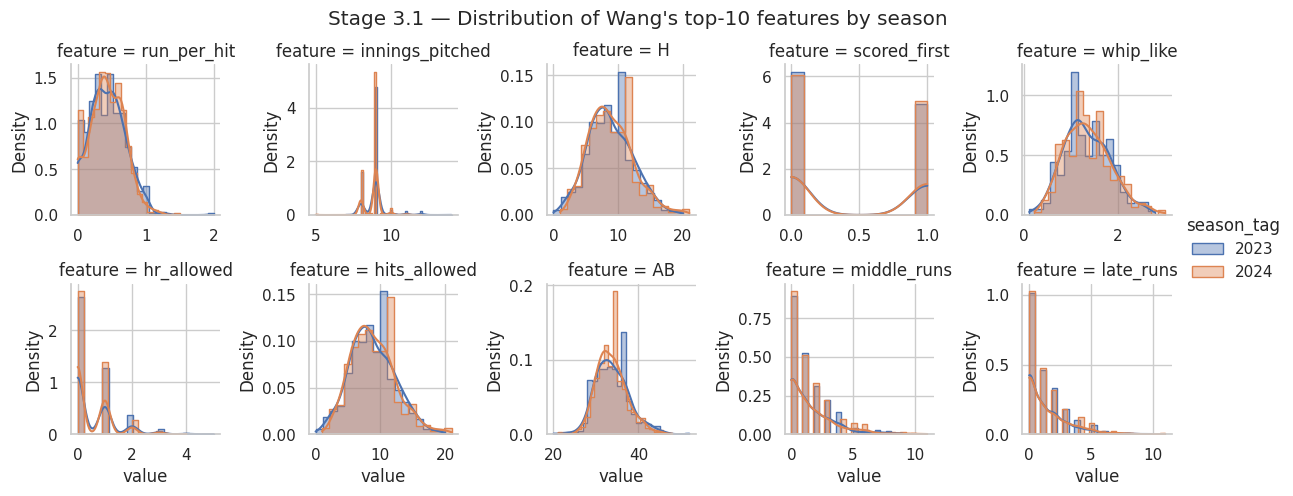

In [18]:
df_long = team_game[WANG_TOP10 + ["season_tag"]].melt(
    id_vars="season_tag", var_name="feature", value_name="value")
g = sns.FacetGrid(df_long, col="feature", col_wrap=5, sharex=False, sharey=False,
                  height=2.4, hue="season_tag")
g.map(sns.histplot, "value", kde=True, stat="density", element="step", alpha=0.4)
g.add_legend()
g.fig.suptitle("Stage 3.1 — Distribution of Wang's top-10 features by season", y=1.03)
show_and_track(g.fig, "stage3_small_multiples_top10.png")
plt.show()

### 3.2 — Masked Spearman correlation heatmap

**【目標 What?】** Heatmap of |Spearman ρ| among all numeric features; mask upper triangle.

**【說明 How to implement?】** `team_game[NUMERIC_FEATURES].corr(method='spearman')`; mask via `np.triu`; diverging palette `coolwarm`.

**【解釋結果 Why? How to explain the result】** Dark cells (>0.9) ⇒ redundancy — one of each pair will be pruned in Stage 4.1.

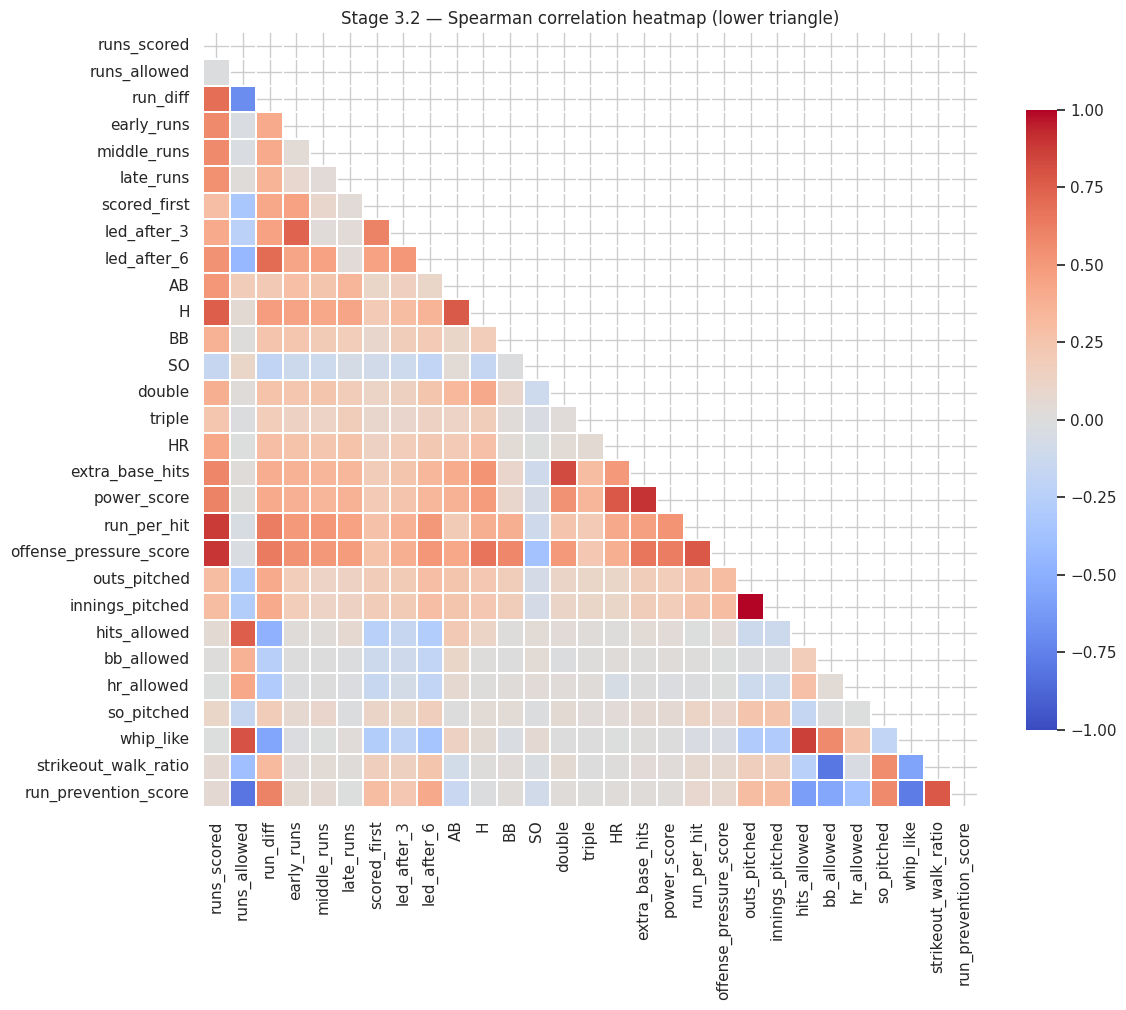

In [19]:
corr_mat = team_game[NUMERIC_FEATURES].corr(method="spearman")
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_mat, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.3, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Stage 3.2 — Spearman correlation heatmap (lower triangle)")
plt.tight_layout()
show_and_track(fig, "stage3_spearman_heatmap.png")
plt.show()

### 3.3 — Pairplot of top-5 features by |ρ| vs win

**【目標 What?】** Scatter+KDE pairplot for the five strongest features.

**【說明 How to implement?】** `sns.pairplot` with `hue='win'`, diag_kind='kde'.

**【解釋結果 Why? How to explain the result】** Cluster-of-win-vs-loss separation in any 2-D corner is an early hint of which feature combinations cleanly split outcomes.

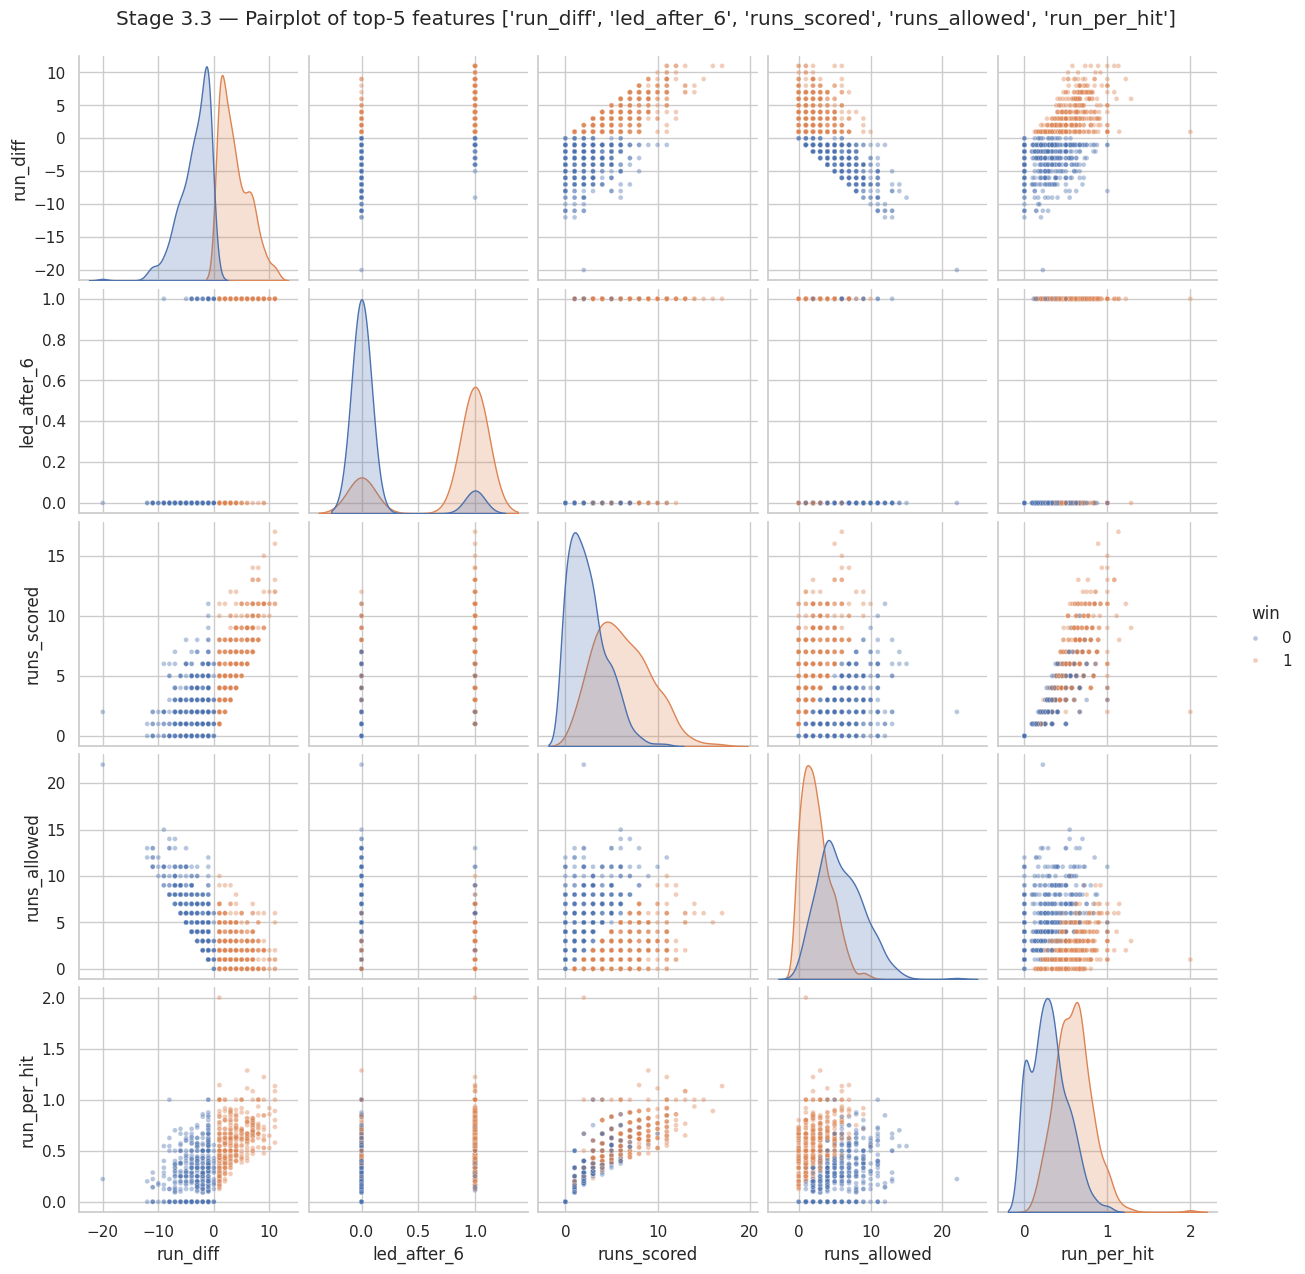

In [20]:
top5 = corr_win.head(5)["feature"].tolist()
g = sns.pairplot(team_game[top5 + ["win"]].dropna().sample(min(800, len(team_game)),
                 random_state=RANDOM_STATE),
                 hue="win", diag_kind="kde", plot_kws={"alpha": .4, "s": 12})
g.fig.suptitle(f"Stage 3.3 — Pairplot of top-5 features {top5}", y=1.02)
show_and_track(g.fig, "stage3_pairplot_top5.png")
plt.show()

### 3.4 — Home vs away mean comparison (grouped bar)

**【目標 What?】** Grouped bar chart: home vs away mean of every Wang-10 feature, faceted by season.

**【說明 How to implement?】** Groupby (season_tag, is_home) → mean → barplot.

**【解釋結果 Why? How to explain the result】** Wang's 2024 finding was a 5.6 pp home win-rate advantage; check whether 2023 repeats it.

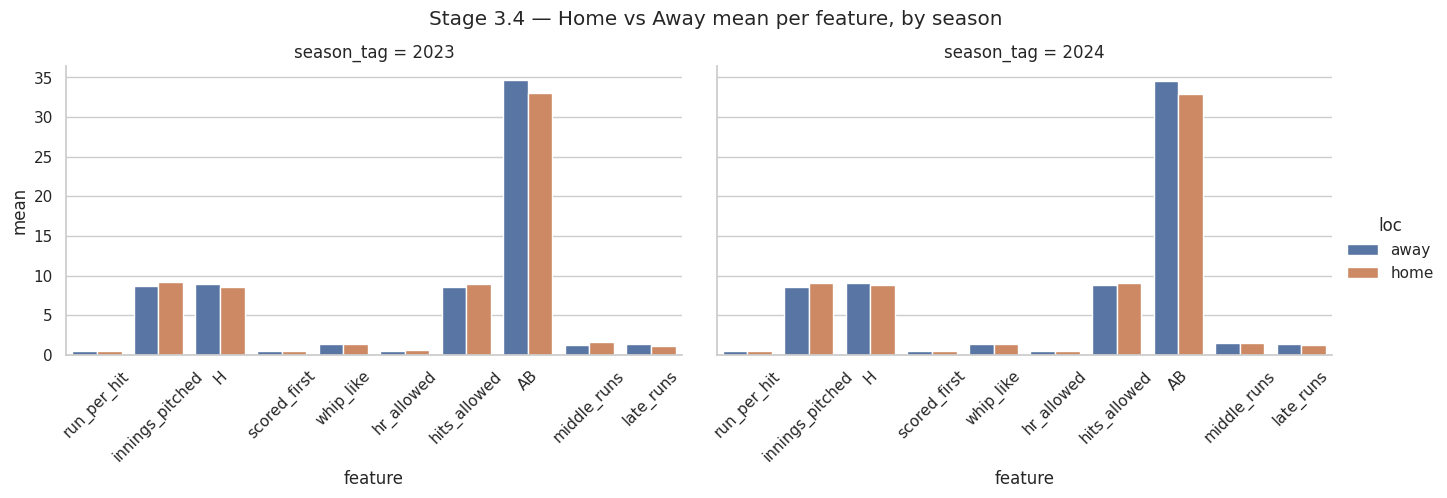

In [21]:
ho = (team_game.groupby(["season_tag", "is_home"])[WANG_TOP10]
      .mean().round(3).reset_index())
ho_long = ho.melt(id_vars=["season_tag", "is_home"], var_name="feature", value_name="mean")
ho_long["loc"] = ho_long["is_home"].map({True: "home", False: "away"})

g = sns.catplot(data=ho_long, x="feature", y="mean", hue="loc",
                col="season_tag", kind="bar", height=4, aspect=1.7)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
g.fig.suptitle("Stage 3.4 — Home vs Away mean per feature, by season", y=1.04)
show_and_track(g.fig, "stage3_home_away_means.png")
plt.show()

### 3.5 — Monthly trajectory of feature means

**【目標 What?】** Line chart: monthly mean of each Wang-10 feature, 2023 vs 2024 overlaid.

**【說明 How to implement?】** Groupby (month, season_tag) → mean; matplotlib subplots 2×5.

**【解釋結果 Why? How to explain the result】** Steep mid-season trends often reveal weather/fatigue effects; level differences between years quantify the meta shift.

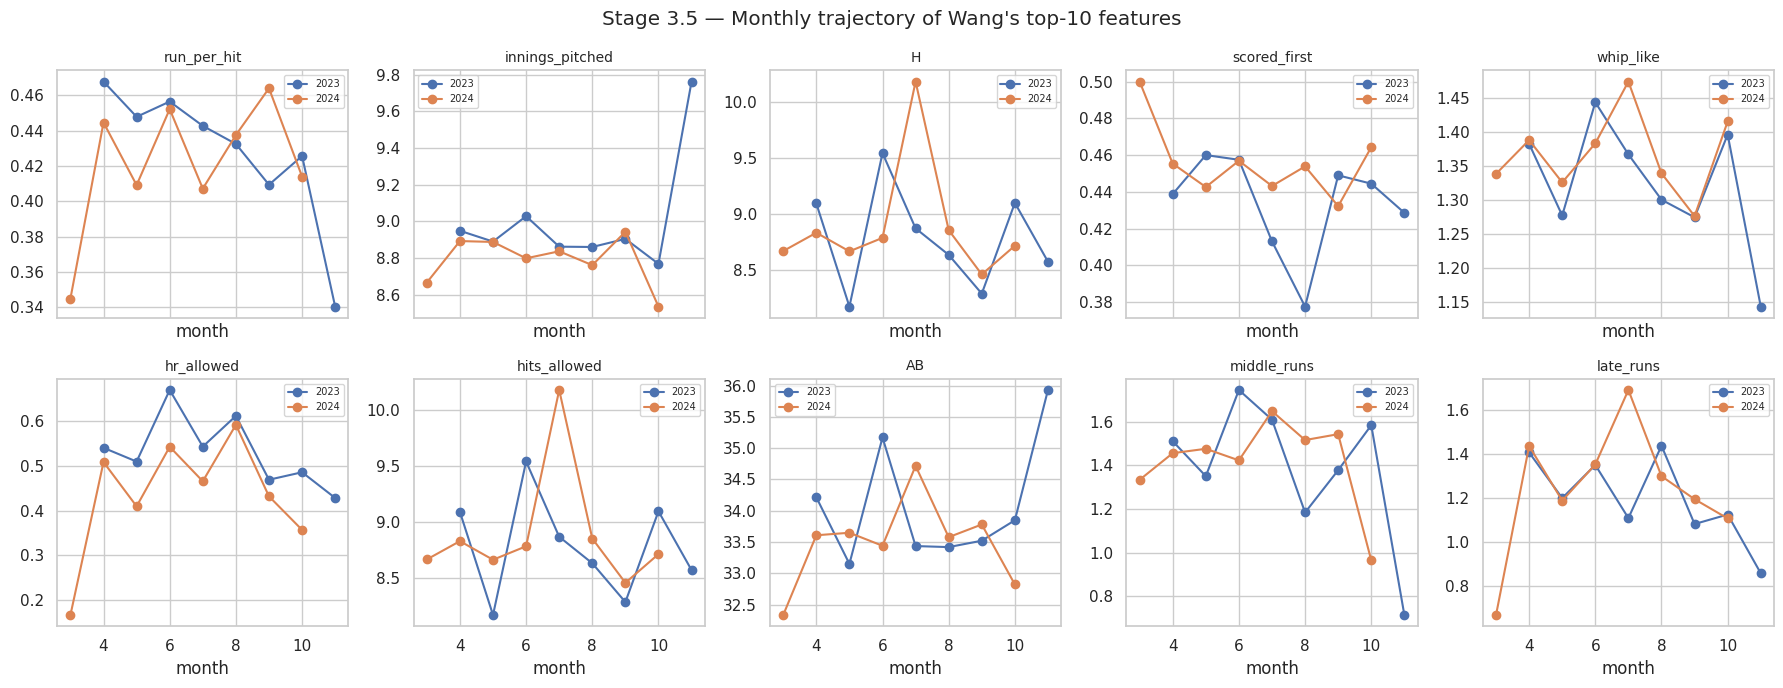

In [22]:
monthly = team_game.groupby(["month", "season_tag"])[WANG_TOP10].mean().reset_index()
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True)
for ax, feat in zip(axes.flat, WANG_TOP10):
    for season, sub in monthly.groupby("season_tag"):
        ax.plot(sub["month"], sub[feat], marker="o", label=season)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("month")
    ax.legend(loc="best", fontsize=7)
fig.suptitle("Stage 3.5 — Monthly trajectory of Wang's top-10 features")
plt.tight_layout()
show_and_track(fig, "stage3_monthly_trajectory.png")
plt.show()

### 3.6 — ECDF panels (skew-tolerant view)

**【目標 What?】** Empirical CDF for each Wang-10 feature; season as hue.

**【說明 How to implement?】** `sns.ecdfplot` in a 2×5 grid.

**【解釋結果 Why? How to explain the result】** ECDF makes long tails visible without binning artefacts; the slope tells you density.

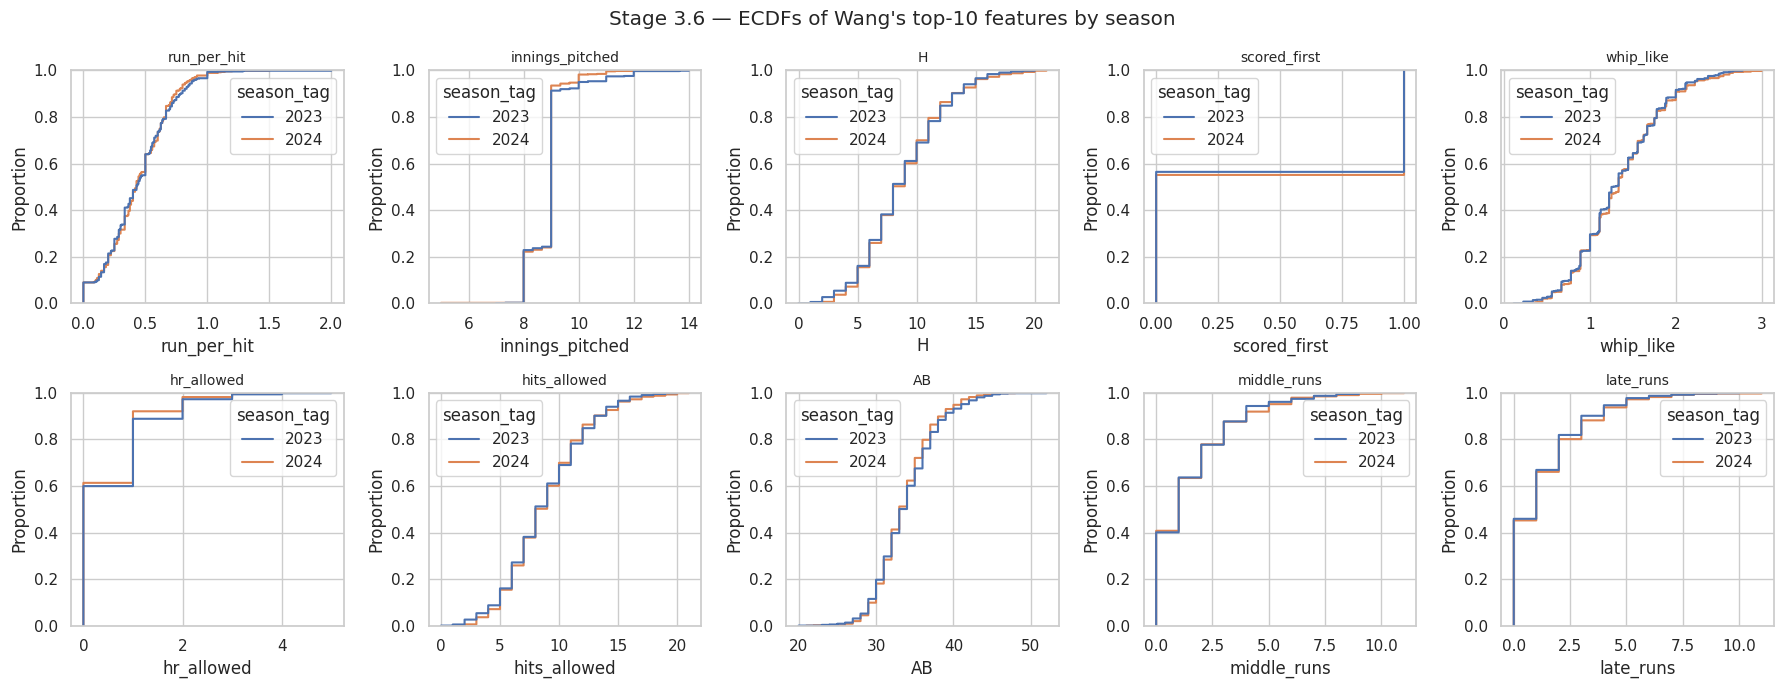

In [23]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, feat in zip(axes.flat, WANG_TOP10):
    sns.ecdfplot(data=team_game, x=feat, hue="season_tag", ax=ax)
    ax.set_title(feat, fontsize=10)
fig.suptitle("Stage 3.6 — ECDFs of Wang's top-10 features by season")
plt.tight_layout()
show_and_track(fig, "stage3_ecdf_top10.png")
plt.show()

### 3.7 — Calendar heatmap of games per stadium

**【目標 What?】** Heatmap: rows = stadium, columns = ISO week, values = games hosted.

**【說明 How to implement?】** Pivot on `(date.isocalendar().week, stadium)`. Separate panels per season.

**【解釋結果 Why? How to explain the result】** Identifies stadium-rich weeks and unusual scheduling; informs whether home-advantage is uniform across venues.

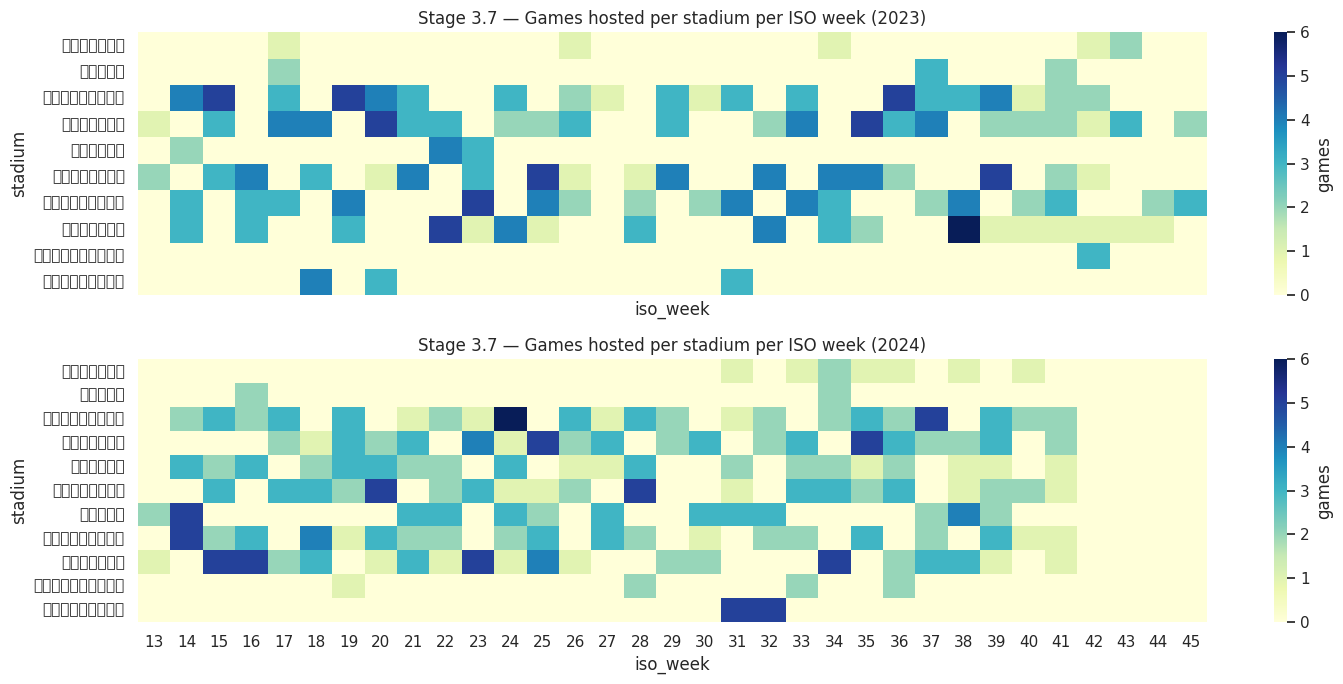

In [24]:
tmp = team_game[team_game["is_home"]].copy()
tmp["iso_week"] = tmp["date"].dt.isocalendar().week.astype(int)
pivot = (tmp.groupby(["stadium", "season_tag", "iso_week"]).size()
            .unstack(fill_value=0))
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
for ax, season in zip(axes, ["2023", "2024"]):
    sub = pivot.xs(season, level="season_tag", drop_level=True) if season in pivot.index.get_level_values(1) else pd.DataFrame()
    if not sub.empty:
        sns.heatmap(sub, cmap="YlGnBu", ax=ax, cbar_kws={"label": "games"})
        ax.set_title(f"Stage 3.7 — Games hosted per stadium per ISO week ({season})")
        ax.set_ylabel("stadium")
plt.tight_layout()
show_and_track(fig, "stage3_calendar_heatmap.png")
plt.show()

### 3.8 — Win-rate by team (home/away breakdown)

**【目標 What?】** Sorted bar chart of overall win-rate per team, with home/away breakdown overlaid.

**【說明 How to implement?】** Group by (team, is_home) → mean(win). Sort teams by overall rate descending.

**【解釋結果 Why? How to explain the result】** Teams with home-rate >> away-rate exhibit Wang's '主場優勢明顯' signature.

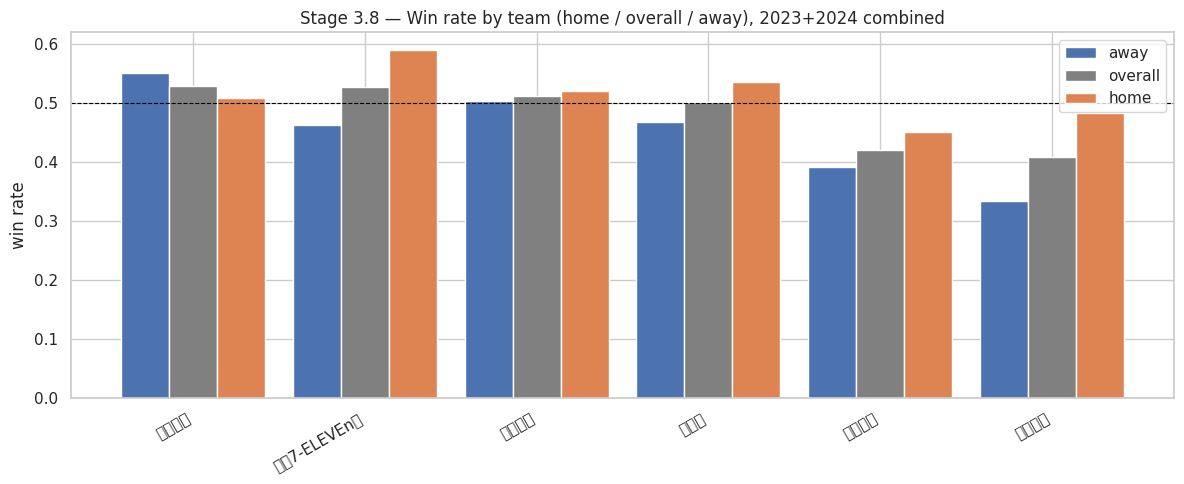

is_home,away,home,overall
team,,,
中信兄弟,0.550,0.508,0.529
統一7-ELEVEn獅,0.463,0.590,0.527
樂天桃猿,0.504,0.520,0.512
味全龍,0.467,0.536,0.502
富邦悍將,0.392,0.450,0.421
台鋼雄鷹,0.333,0.483,0.408


In [25]:
wr = team_game.groupby(["team", "is_home"])["win"].mean().unstack().rename(
    columns={False: "away", True: "home"})
wr["overall"] = team_game.groupby("team")["win"].mean()
wr = wr.sort_values("overall", ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(wr))
w = 0.28
ax.bar(x - w, wr["away"], width=w, label="away")
ax.bar(x, wr["overall"], width=w, label="overall", color="grey")
ax.bar(x + w, wr["home"], width=w, label="home")
ax.set_xticks(x)
ax.set_xticklabels(wr.index, rotation=30, ha="right")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_ylabel("win rate")
ax.set_title("Stage 3.8 — Win rate by team (home / overall / away), 2023+2024 combined")
ax.legend()
plt.tight_layout()
show_and_track(fig, "stage3_win_rate_by_team.png")
plt.show()
display(wr.round(3))

### 3.9 — Hexbin: H vs run_diff per season

**【目標 What?】** Hexbin density plot showing H (offense volume) against run_diff for each season.

**【說明 How to implement?】** Two subplots side-by-side, `plt.hexbin` with `gridsize=30`.

**【解釋結果 Why? How to explain the result】** Hot cells near (H ≥ 9, run_diff > 0) are 'blowout offense' archetypes; (H small, run_diff > 0) is the 'pitcher duel win'.

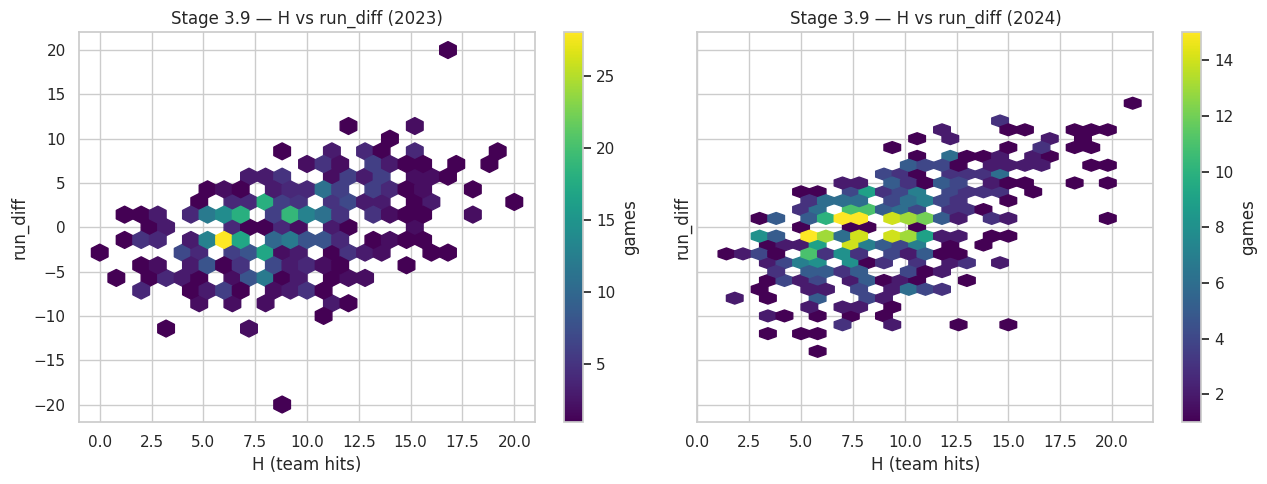

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, season in zip(axes, ["2023", "2024"]):
    sub = team_game[team_game["season_tag"] == season]
    hb = ax.hexbin(sub["H"], sub["run_diff"], gridsize=25, cmap="viridis", mincnt=1)
    ax.set_xlabel("H (team hits)"); ax.set_ylabel("run_diff")
    ax.set_title(f"Stage 3.9 — H vs run_diff ({season})")
    fig.colorbar(hb, ax=ax, label="games")
plt.tight_layout()
show_and_track(fig, "stage3_hexbin_H_run_diff.png")
plt.show()

### 3.10 — Per-team violin of top features

**【目標 What?】** Violin grid: distribution of each top-3 (by |ρ| vs win) feature, per team.

**【說明 How to implement?】** `sns.violinplot` with `inner='quartile'`, faceted via a small loop.

**【解釋結果 Why? How to explain the result】** Teams with wider violins ⇒ more variability ⇒ potentially split across multiple clusters in Stage 4.

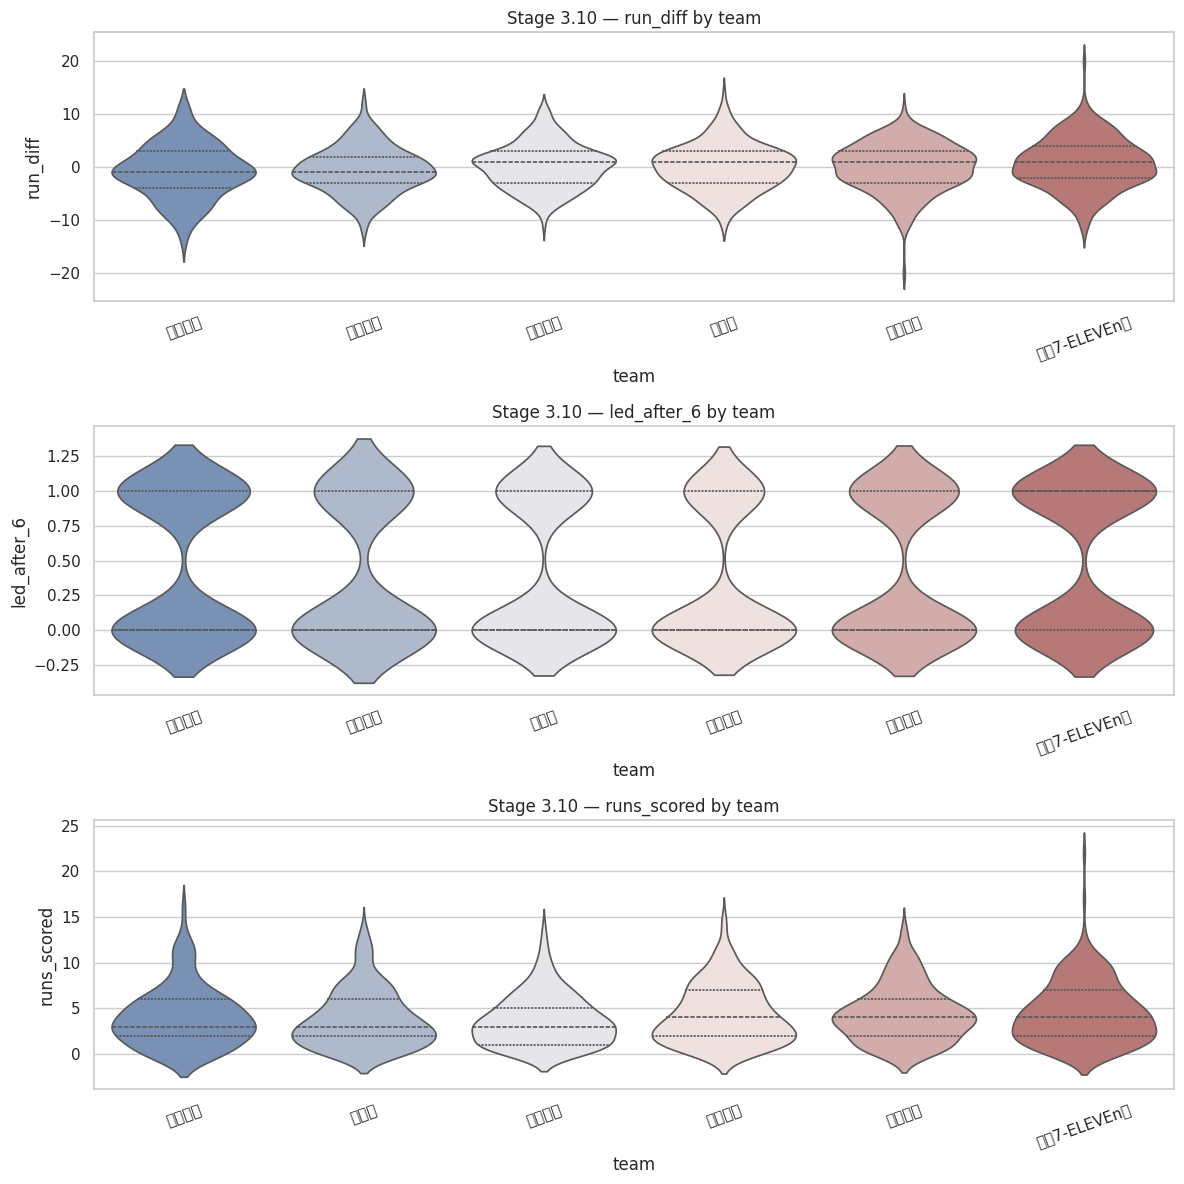

In [27]:
top3 = corr_win.head(3)["feature"].tolist()
fig, axes = plt.subplots(len(top3), 1, figsize=(12, 4 * len(top3)))
for ax, feat in zip(axes, top3):
    order = team_game.groupby("team")[feat].median().sort_values().index
    sns.violinplot(data=team_game, x="team", y=feat, order=order,
                   inner="quartile", ax=ax, palette="vlag")
    ax.set_title(f"Stage 3.10 — {feat} by team")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
show_and_track(fig, "stage3_violin_per_team.png")
plt.show()

## Stage 4 — Unsupervised Feature Discovery

*KB ← `topic05-1_PCA-SVD` + `topic05_featureReduction` + `topic05-2_featureExplain` + `topic08_unsupervised` + `topic09_supervised1_mem`*

### 4.1 — Filter pruning — variance threshold + |ρ| ≥ 0.95 redundancy drop

**【目標 What?】** Remove zero/near-zero-variance features and one of each pair with |Spearman ρ| ≥ 0.95.

**【說明 How to implement?】** `VarianceThreshold(0.01)` on z-scored data; then walk the |ρ| matrix and drop the second feature of each near-perfect pair (keep the more interpretable one when possible).

**【解釋結果 Why? How to explain the result】** We log every drop with its reason. Final kept-list typically falls from ~30 → 18-22.

In [28]:
def filter_prune(df, cols, rho_thresh=0.95):
    X = df[cols].astype(float).copy()
    # 1. Variance threshold on z-scored values (so 'variance ≈ 0' is scale-invariant)
    z = (X - X.mean()) / X.std(ddof=0).replace(0, np.nan)
    keep = z.var().fillna(0)
    near_zero = keep[keep < 0.01].index.tolist()
    surviving = [c for c in cols if c not in near_zero]

    # 2. Pairwise |Spearman| pruning
    rho = X[surviving].corr(method="spearman").abs()
    drop = set()
    for i, a in enumerate(rho.columns):
        if a in drop: continue
        for b in rho.columns[i+1:]:
            if b in drop: continue
            if rho.loc[a, b] >= rho_thresh:
                # Keep the one with shorter name (cosmetic; usually the simpler concept)
                victim = b if len(b) >= len(a) else a
                keeper = a if victim == b else b
                drop.add(victim)
    surviving = [c for c in surviving if c not in drop]
    return surviving, near_zero, sorted(drop)

KEPT, NZ_DROP, RHO_DROP = filter_prune(team_game, NUMERIC_FEATURES)

report = pd.DataFrame({
    "stage": ["start"] + ["near-zero variance"] * len(NZ_DROP) +
             ["|ρ|≥0.95 redundancy"] * len(RHO_DROP) + ["surviving"],
    "feature": [f"({len(NUMERIC_FEATURES)} features)"] +
               NZ_DROP + RHO_DROP +
               [f"({len(KEPT)} features)"],
})
show_and_track(report, "stage4_filter_prune_log.csv", "table")
display(report)
print(f"\nKept features ({len(KEPT)}): {KEPT}")

,stage,feature
0,start,(29 features)
1,|ρ|≥0.95 redundancy,innings_pitched
2,surviving,(28 features)



Kept features (28): ['runs_scored', 'runs_allowed', 'run_diff', 'early_runs', 'middle_runs', 'late_runs', 'scored_first', 'led_after_3', 'led_after_6', 'AB', 'H', 'BB', 'SO', 'double', 'triple', 'HR', 'extra_base_hits', 'power_score', 'run_per_hit', 'offense_pressure_score', 'outs_pitched', 'hits_allowed', 'bb_allowed', 'hr_allowed', 'so_pitched', 'whip_like', 'strikeout_walk_ratio', 'run_prevention_score']


### 4.2 — Standardise — RobustScaler for heavy-tailed, StandardScaler for symmetric

**【目標 What?】** Build a `ColumnTransformer` that applies the right scaler per column group.

**【說明 How to implement?】** `ColumnTransformer([('robust', RobustScaler(), HEAVY_TAIL_kept), ('std', StandardScaler(), SYMMETRIC_kept)])`. Median-impute missing values via `SimpleImputer` inside each pipeline.

**【解釋結果 Why? How to explain the result】** All scaled columns have median ≈ 0, IQR ≈ 1 (robust) or mean ≈ 0, std ≈ 1 (standard). `describe().T` printed for sanity.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

HT_kept = [c for c in HEAVY_TAIL if c in KEPT]
SYM_kept = [c for c in KEPT if c not in HT_kept]

scaler = ColumnTransformer(
    transformers=[
        ("robust", Pipeline([("imp", SimpleImputer(strategy="median")),
                             ("sc", RobustScaler())]), HT_kept),
        ("std",    Pipeline([("imp", SimpleImputer(strategy="median")),
                             ("sc", StandardScaler())]), SYM_kept),
    ],
    remainder="drop",
)
X_scaled = scaler.fit_transform(team_game[KEPT])
X_scaled = pd.DataFrame(X_scaled, columns=HT_kept + SYM_kept, index=team_game.index)
print(f"X_scaled shape: {X_scaled.shape}")
desc_scaled = X_scaled.describe().T.round(3)
show_and_track(desc_scaled, "stage4_scaled_describe.csv", "table")
display(desc_scaled)

X_scaled shape: (1340, 28)


,count,mean,std,min,25%,50%,75%,max
whip_like,1340.0,0.026,0.745,-1.833,-0.500,0.000,0.500,2.500
run_per_hit,1340.0,0.022,0.689,-1.143,-0.476,0.000,0.524,4.190
strikeout_walk_ratio,1340.0,0.279,0.939,-0.875,-0.375,0.000,0.625,4.750
offense_pressure_score,1340.0,0.079,0.743,-1.467,-0.467,0.000,0.533,3.400
run_prevention_score,1340.0,-0.026,0.697,-2.625,-0.500,0.000,0.500,1.875
power_score,1340.0,0.085,0.701,-0.750,-0.500,0.000,0.500,3.500
runs_scored,1340.0,-0.000,1.000,-1.331,-0.693,-0.055,0.583,5.685
runs_allowed,1340.0,-0.000,1.000,-1.331,-0.693,-0.055,0.583,5.685
run_diff,1340.0,0.000,1.000,-4.489,-0.673,0.000,0.673,4.489
early_runs,1340.0,0.000,1.000,-0.782,-0.782,-0.199,0.385,5.636


### 4.3 — PCA — scree + cumulative PVE

**【目標 What?】** Fit PCA on the scaled matrix; show eigenvalue scree and cumulative variance explained.

**【說明 How to implement?】** `PCA(n_components=None, random_state=42).fit(X_scaled)`. Plot bar (PVE) + line (cumulative).

**【解釋結果 Why? How to explain the result】** Look for the elbow + the k where cumulative ≥ 0.90 — both decide how many PCs we keep for clustering.

PCs needed for ≥90% PVE: 13  (cumulative PVE: 0.911)


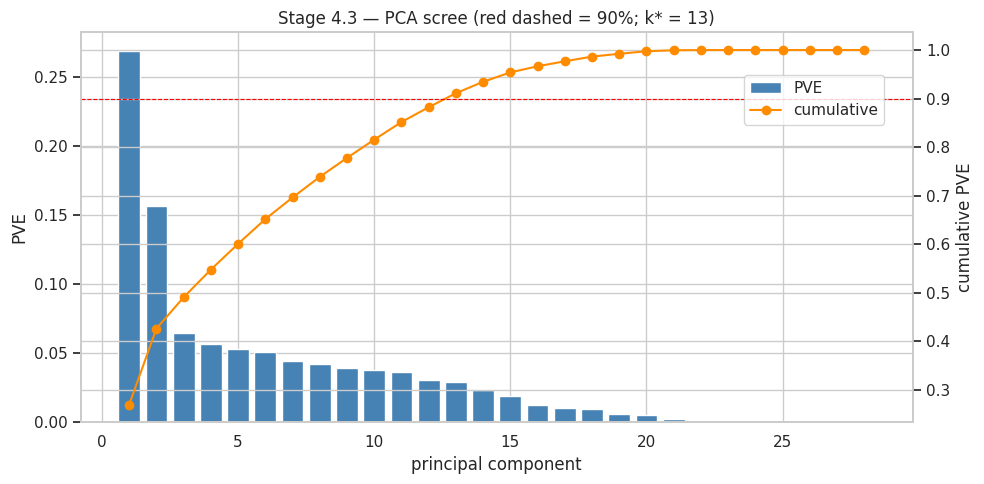

In [30]:
pca_full = PCA(n_components=None, random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
pve = pca_full.explained_variance_ratio_
cum = np.cumsum(pve)
K_PCA = int(np.searchsorted(cum, 0.90) + 1)
print(f"PCs needed for ≥90% PVE: {K_PCA}  (cumulative PVE: {cum[K_PCA-1]:.3f})")

fig, ax = plt.subplots(figsize=(10, 5))
xs = np.arange(1, len(pve) + 1)
ax.bar(xs, pve, color="steelblue", label="PVE")
ax2 = ax.twinx()
ax2.plot(xs, cum, color="darkorange", marker="o", label="cumulative")
ax2.axhline(0.9, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("principal component"); ax.set_ylabel("PVE"); ax2.set_ylabel("cumulative PVE")
ax.set_title(f"Stage 4.3 — PCA scree (red dashed = 90%; k* = {K_PCA})")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.85))
plt.tight_layout()
show_and_track(fig, "stage4_pca_scree.png")
plt.show()

X_pca = PCA(n_components=K_PCA, random_state=RANDOM_STATE).fit_transform(X_scaled)
X_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(K_PCA)], index=team_game.index)

### 4.3a — PCA biplot — feature-name arrows on PC1 vs PC2

**【目標 What?】** Scatter of team-game rows on PC1–PC2 with overlaid loading arrows labelled with feature names.

**【說明 How to implement?】** Use first two PCs from pca_full; loadings = components_.T * sqrt(explained_variance_). Quiver arrows scaled to fit; hue by `scored_first`.

**【解釋結果 Why? How to explain the result】** Arrows pointing in the same direction ⇒ features synergise on that PC. Wang's offense features should cluster on one side, pitching on the other.

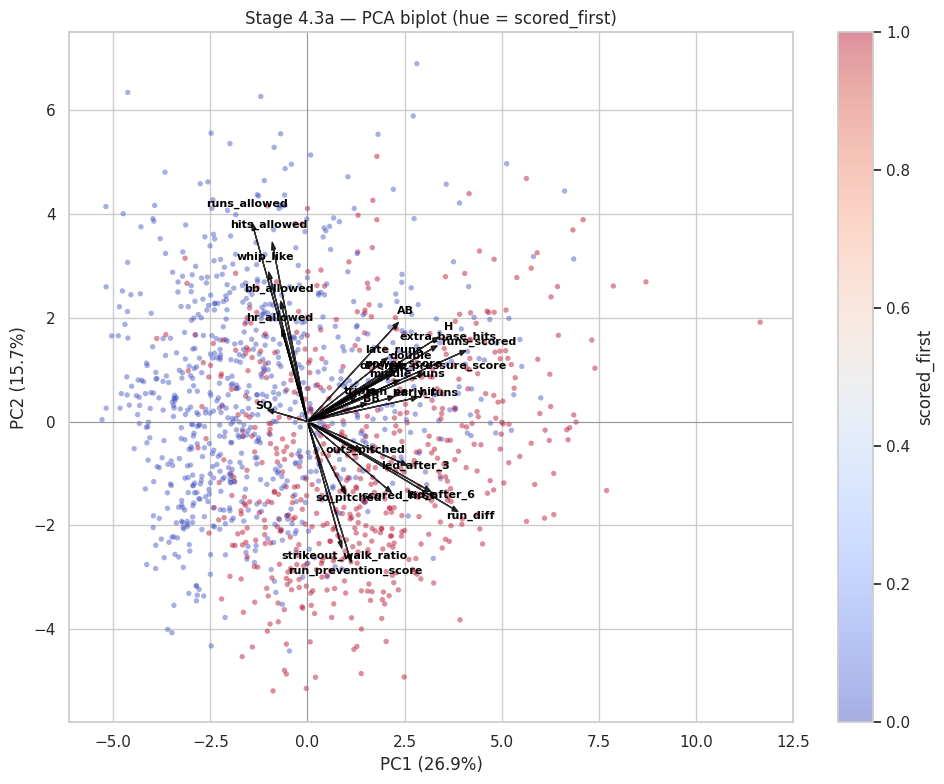

In [31]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit(X_scaled)
scores2 = pca2.transform(X_scaled)
loadings2 = pca2.components_.T * np.sqrt(pca2.explained_variance_)

fig, ax = plt.subplots(figsize=(10, 8))
hue = team_game.loc[X_scaled.index, "scored_first"].astype(int)
sc = ax.scatter(scores2[:, 0], scores2[:, 1], c=hue, cmap="coolwarm",
                alpha=0.45, s=15, edgecolor="none")
arrow_scale = 0.35 * max(abs(scores2[:, 0]).max(), abs(scores2[:, 1]).max()) / np.abs(loadings2).max()
for i, feat in enumerate(X_scaled.columns):
    dx, dy = loadings2[i] * arrow_scale
    ax.arrow(0, 0, dx, dy, color="black", alpha=0.8, head_width=0.1, length_includes_head=True)
    ax.text(dx * 1.08, dy * 1.08, feat, fontsize=8, ha="center",
            color="black", weight="bold")
ax.axhline(0, color="grey", lw=.5); ax.axvline(0, color="grey", lw=.5)
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]:.1%})")
ax.set_title("Stage 4.3a — PCA biplot (hue = scored_first)")
plt.colorbar(sc, ax=ax, label="scored_first")
plt.tight_layout()
show_and_track(fig, "stage4_pca_biplot.png")
plt.show()

### 4.3b — Loadings narrative table & corroboration check

**【目標 What?】** Show |loading| matrix for PC1..PC_k* and verify how many of Wang's top-10 appear with high loading on PC1+PC2.

**【說明 How to implement?】** `abs(loadings)` for the first k* PCs; report top-5 features per PC; assertion that ≥ 6 of Wang's 10 are in the top-|loading| of PC1+PC2 combined.

**【解釋結果 Why? How to explain the result】** Pass ⇒ unsupervised PCA independently recovers Wang's supervised feature shortlist. Fail ⇒ either scaling is off or Wang's supervised signal isn't axis-aligned.

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
whip_like,0.219,0.630,0.121,0.036,0.035,0.038,0.094,0.030,0.053,0.066,0.059,0.190,0.024
run_per_hit,0.486,0.104,0.047,0.061,0.023,0.240,0.095,0.145,0.050,0.057,0.055,0.036,0.049
strikeout_walk_ratio,0.194,0.534,0.309,0.496,0.291,0.023,0.073,0.131,0.017,0.012,0.045,0.115,0.050
offense_pressure_score,0.656,0.203,0.021,0.025,0.029,0.214,0.049,0.030,0.062,0.119,0.033,0.013,0.076
run_prevention_score,0.247,0.592,0.166,0.111,0.012,0.031,0.053,0.006,0.017,0.065,0.025,0.088,0.005
power_score,0.499,0.213,0.120,0.156,0.101,0.210,0.232,0.151,0.018,0.060,0.038,0.089,0.099
runs_scored,0.891,0.298,0.027,0.001,0.036,0.197,0.053,0.102,0.003,0.035,0.062,0.084,0.123
runs_allowed,0.312,0.836,0.070,0.254,0.147,0.060,0.096,0.041,0.009,0.034,0.033,0.083,0.020
run_diff,0.847,0.379,0.068,0.180,0.129,0.096,0.105,0.043,0.008,0.049,0.020,0.001,0.101
early_runs,0.618,0.101,0.559,0.178,0.132,0.102,0.027,0.052,0.060,0.022,0.039,0.075,0.010


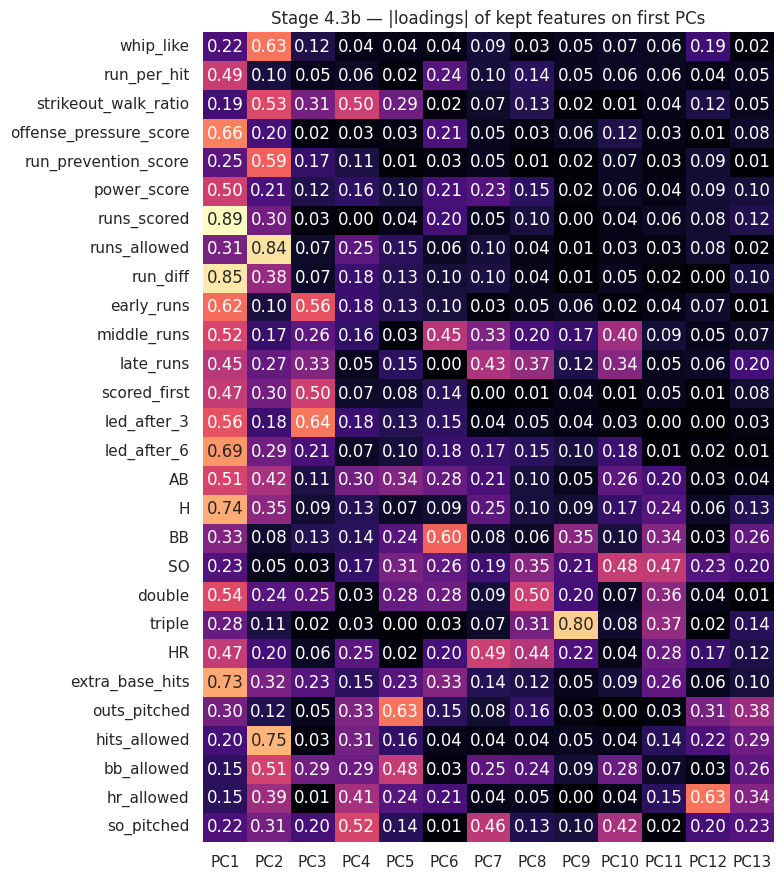


Wang top-10 in top |loadings| of PC1+PC2 only : 5/10 → ['H', 'whip_like', 'hr_allowed', 'hits_allowed', 'AB']
Wang top-10 in top |loadings| across all 13 PCs: 8/10 → ['H', 'scored_first', 'whip_like', 'hr_allowed', 'hits_allowed', 'AB', 'middle_runs', 'late_runs']


In [32]:
pca_k = PCA(n_components=K_PCA, random_state=RANDOM_STATE).fit(X_scaled)
loadings_k = pd.DataFrame(
    (pca_k.components_.T * np.sqrt(pca_k.explained_variance_)),
    index=X_scaled.columns,
    columns=[f"PC{i+1}" for i in range(K_PCA)],
)
loadings_abs = loadings_k.abs().round(3)
show_and_track(loadings_abs, "stage4_pca_loadings_abs.csv", "table")
display(loadings_abs)

# Heatmap
fig, ax = plt.subplots(figsize=(8, max(6, 0.32 * len(loadings_abs))))
sns.heatmap(loadings_abs, cmap="magma", annot=True, fmt=".2f", ax=ax, cbar=False)
ax.set_title("Stage 4.3b — |loadings| of kept features on first PCs")
plt.tight_layout()
show_and_track(fig, "stage4_loadings_heatmap.png")
plt.show()

# Corroboration check: PC1+PC2 (strict) and across all kept PCs (relaxed)
top_loadings_12 = set(
    loadings_abs["PC1"].nlargest(8).index.tolist() +
    loadings_abs["PC2"].nlargest(8).index.tolist()
)
top_loadings_all = set()
for pc in loadings_abs.columns:
    top_loadings_all.update(loadings_abs[pc].nlargest(6).index.tolist())
rec12 = [f for f in WANG_TOP10 if f in top_loadings_12]
rec_all = [f for f in WANG_TOP10 if f in top_loadings_all]
print(f"\nWang top-10 in top |loadings| of PC1+PC2 only : "
      f"{len(rec12)}/10 → {rec12}")
print(f"Wang top-10 in top |loadings| across all {K_PCA} PCs: "
      f"{len(rec_all)}/10 → {rec_all}")

### 4.3c — 3-D PCA scatter (plotly)

**【目標 What?】** Interactive 3-D scatter of PC1/PC2/PC3 coloured by season — eye-catching view.

**【說明 How to implement?】** `plotly.express.scatter_3d` with `color='season_tag'`, hover_data includes team and date.

**【解釋結果 Why? How to explain the result】** Rotate to see whether 2023 and 2024 occupy the same manifold or different sub-volumes.

In [33]:
if K_PCA >= 3:
    df_pca3 = X_pca.iloc[:, :3].copy()
    df_pca3.columns = ["PC1", "PC2", "PC3"]
    df_pca3["season_tag"] = team_game.loc[df_pca3.index, "season_tag"].values
    df_pca3["team"] = team_game.loc[df_pca3.index, "team"].values
    df_pca3["date"] = team_game.loc[df_pca3.index, "date"].astype(str).values
    fig = px.scatter_3d(df_pca3, x="PC1", y="PC2", z="PC3",
                        color="season_tag", hover_data=["team", "date"],
                        opacity=0.6, title="Stage 4.3c — 3-D PCA scatter")
    fig.update_traces(marker=dict(size=3))
    show_and_track(fig, "stage4_pca_3d.html")
    fig.show()
else:
    print(f"Skipped: K_PCA = {K_PCA} < 3")

### 4.4 — K-Means — elbow + silhouette + Calinski-Harabasz panel

**【目標 What?】** Try k = 2..10 with K-Means; record inertia, silhouette, CH.

**【說明 How to implement?】** Loop K-Means(n_init=10) over k; plot 3 panels.

**【解釋結果 Why? How to explain the result】** Elbow + silhouette peak typically agree on the natural k. We'll use the best for the final model below.

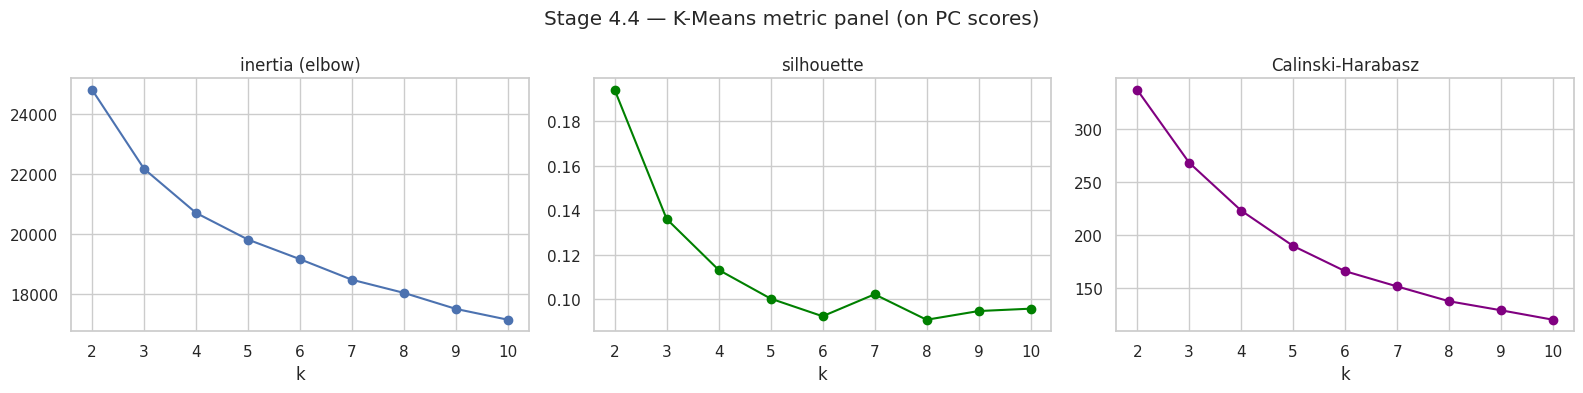

Best k by silhouette: 2


In [34]:
ks = range(2, 11)
km_metrics = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca)
    labels = km.labels_
    km_metrics.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_pca, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca, labels),
    })
km_df = pd.DataFrame(km_metrics)
show_and_track(km_df.round(3), "stage4_kmeans_metrics.csv", "table")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(km_df["k"], km_df["inertia"], "o-"); axes[0].set_title("inertia (elbow)")
axes[1].plot(km_df["k"], km_df["silhouette"], "o-", color="green"); axes[1].set_title("silhouette")
axes[2].plot(km_df["k"], km_df["calinski_harabasz"], "o-", color="purple"); axes[2].set_title("Calinski-Harabasz")
for ax in axes: ax.set_xlabel("k")
fig.suptitle("Stage 4.4 — K-Means metric panel (on PC scores)")
plt.tight_layout()
show_and_track(fig, "stage4_kmeans_panel.png")
plt.show()

K_KM = int(km_df.loc[km_df["silhouette"].idxmax(), "k"])
print(f"Best k by silhouette: {K_KM}")

### 4.5 — Ward agglomerative + dendrogram + cophenetic

**【目標 What?】** Fit Ward linkage on PC scores; show dendrogram and report cophenetic correlation.

**【說明 How to implement?】** `scipy.cluster.hierarchy.linkage(X_pca, method='ward')`; `dendrogram(truncate_mode='lastp', p=30)`; `cophenet(Z, pdist(X_pca))[0]`.

**【解釋結果 Why? How to explain the result】** Cophenetic > 0.7 ⇒ the tree faithfully preserves distances. Big horizontal gaps in the dendrogram suggest a natural k.

Cophenetic correlation: 0.362


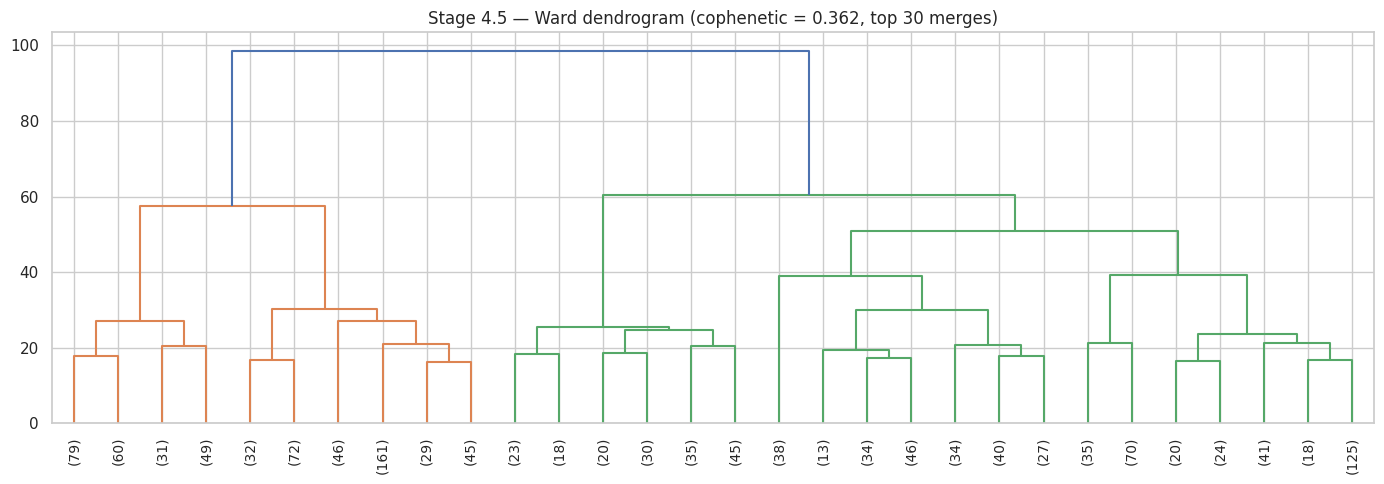

In [35]:
Z = linkage(X_pca, method="ward")
coph, _ = cophenet(Z, pdist(X_pca))
print(f"Cophenetic correlation: {coph:.3f}")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, ax=ax,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title(f"Stage 4.5 — Ward dendrogram (cophenetic = {coph:.3f}, top 30 merges)")
plt.tight_layout()
show_and_track(fig, "stage4_dendrogram.png")
plt.show()

### 4.6 — GMM — BIC vs k

**【目標 What?】** Fit GMM for k = 2..10 with diagonal covariance; pick k by BIC.

**【說明 How to implement?】** Loop `GaussianMixture(covariance_type='diag', n_init=3, random_state=42)`.

**【解釋結果 Why? How to explain the result】** BIC elbow suggests the most parsimonious k. We'll keep `predict_proba` later as soft cluster features.

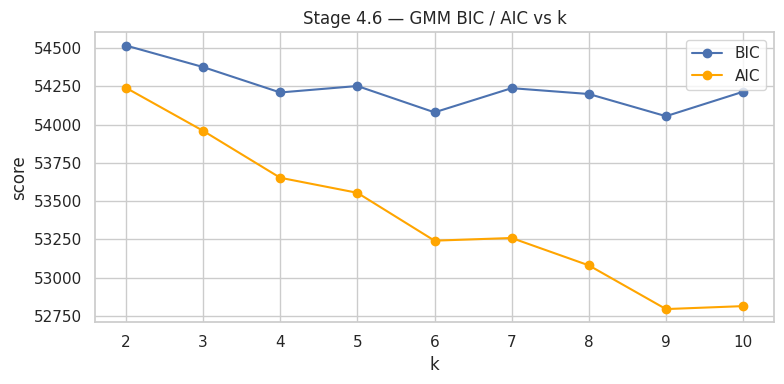

Best k by BIC: 9


In [36]:
gm_metrics = []
for k in ks:
    gm = GaussianMixture(n_components=k, covariance_type="diag",
                         n_init=3, random_state=RANDOM_STATE).fit(X_pca)
    gm_metrics.append({"k": k, "bic": gm.bic(X_pca), "aic": gm.aic(X_pca)})
gm_df = pd.DataFrame(gm_metrics)
show_and_track(gm_df.round(2), "stage4_gmm_metrics.csv", "table")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gm_df["k"], gm_df["bic"], "o-", label="BIC")
ax.plot(gm_df["k"], gm_df["aic"], "o-", color="orange", label="AIC")
ax.set_xlabel("k"); ax.set_ylabel("score"); ax.legend()
ax.set_title("Stage 4.6 — GMM BIC / AIC vs k")
plt.tight_layout()
show_and_track(fig, "stage4_gmm_bic.png")
plt.show()

K_GMM = int(gm_df.loc[gm_df["bic"].idxmin(), "k"])
print(f"Best k by BIC: {K_GMM}")

### 4.7 — HDBSCAN — auto-k clustering with noise

**【目標 What?】** Density-based clustering; outliers labelled −1.

**【說明 How to implement?】** `hdbscan.HDBSCAN(min_cluster_size=30, prediction_data=True)`.

**【解釋結果 Why? How to explain the result】** If most points fall into 2–4 dense regions with a few noise points, the data has clear archetypes. If everything is noise, lower `min_cluster_size`.

HDBSCAN clusters: 0  | noise points: 1340 / 1340


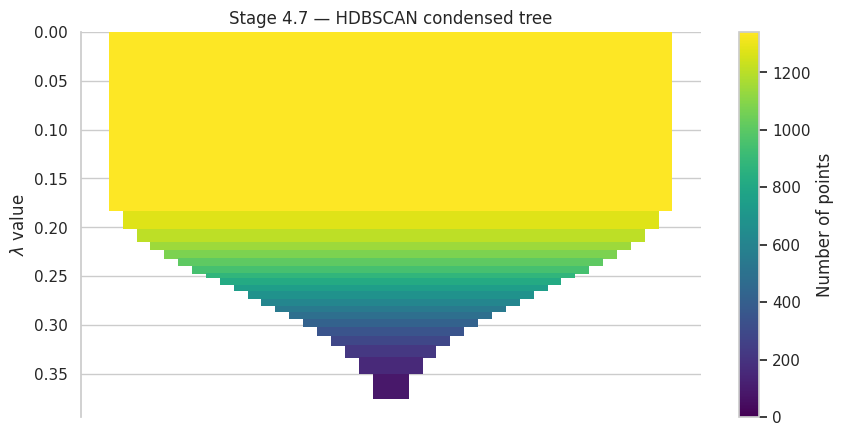

In [37]:
hdb = hdbscan.HDBSCAN(min_cluster_size=max(30, len(X_pca)//40),
                      prediction_data=True).fit(X_pca.values)
labels_hdb = hdb.labels_
n_clusters_hdb = labels_hdb.max() + 1
n_noise = (labels_hdb == -1).sum()
print(f"HDBSCAN clusters: {n_clusters_hdb}  | noise points: {n_noise} / {len(labels_hdb)}")

fig, ax = plt.subplots(figsize=(10, 5))
hdb.condensed_tree_.plot(select_clusters=True,
                          selection_palette=sns.color_palette("deep", max(n_clusters_hdb, 1)),
                          axis=ax)
ax.set_title("Stage 4.7 — HDBSCAN condensed tree")
show_and_track(fig, "stage4_hdbscan_tree.png")
plt.show()

### 4.8 — Validity panel — silhouette / CH / DBI / bootstrap-Jaccard

**【目標 What?】** For each algorithm at its chosen k, compute the four metrics and bootstrap-Jaccard stability.

**【說明 How to implement?】** Bootstrap: B=50 resamples (with replacement); refit; compute pairwise Jaccard between original clusters and resampled clusters via greedy matching. Stability = average max-Jaccard.

**【解釋結果 Why? How to explain the result】** Per the plan, we require silhouette ≥ 0.25 AND Jaccard ≥ 0.75 for the final algo. Whichever passes with the highest combined score wins.

In [38]:
def fit_predict(name, k):
    if name == "kmeans":
        return KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca).labels_
    if name == "ward":
        return AgglomerativeClustering(n_clusters=k, linkage="ward").fit(X_pca).labels_
    if name == "gmm":
        return GaussianMixture(n_components=k, covariance_type="diag",
                               n_init=3, random_state=RANDOM_STATE).fit(X_pca).predict(X_pca)
    raise ValueError(name)

def jaccard_stability(name, k, B=50, frac=0.8):
    base = fit_predict(name, k)
    rng = np.random.default_rng(RANDOM_STATE)
    stabilities = []
    n = len(X_pca)
    for _ in range(B):
        idx = rng.choice(n, size=int(frac*n), replace=False)
        Xb = X_pca.iloc[idx]
        if name == "kmeans":
            lab = KMeans(n_clusters=k, n_init=5, random_state=int(rng.integers(1e9))).fit(Xb).labels_
        elif name == "ward":
            lab = AgglomerativeClustering(n_clusters=k, linkage="ward").fit(Xb).labels_
        else:
            lab = GaussianMixture(n_components=k, covariance_type="diag",
                                  n_init=1, random_state=int(rng.integers(1e9))).fit(Xb).predict(Xb)
        # match base[idx] to lab via greedy max-Jaccard
        base_idx = base[idx]
        max_jaccards = []
        for c in np.unique(base_idx):
            mask_b = base_idx == c
            best = 0
            for c2 in np.unique(lab):
                mask_l = lab == c2
                inter = (mask_b & mask_l).sum()
                union = (mask_b | mask_l).sum()
                if union > 0:
                    best = max(best, inter / union)
            max_jaccards.append(best)
        stabilities.append(np.mean(max_jaccards))
    return float(np.mean(stabilities))

rows = []
candidates = [("kmeans", K_KM), ("ward", K_KM), ("gmm", K_GMM)]
for name, k in candidates:
    lab = fit_predict(name, k)
    sil = silhouette_score(X_pca, lab)
    ch = calinski_harabasz_score(X_pca, lab)
    dbi = davies_bouldin_score(X_pca, lab)
    jac = jaccard_stability(name, k, B=50)
    rows.append({"algo": name, "k": k, "silhouette": sil,
                 "CH": ch, "DBI": dbi, "bootstrap_jaccard": jac})
validity = pd.DataFrame(rows).round(3)
show_and_track(validity, "stage4_validity_panel.csv", "table")

styled = validity.style.background_gradient(subset=["silhouette","CH","bootstrap_jaccard"], cmap="Greens")\
                       .background_gradient(subset=["DBI"], cmap="Greens_r")
display(styled)

passes = validity[(validity["silhouette"] >= 0.25) & (validity["bootstrap_jaccard"] >= 0.75)]
if len(passes):
    chosen = passes.sort_values(["silhouette","bootstrap_jaccard"], ascending=False).iloc[0]
else:
    chosen = validity.sort_values("silhouette", ascending=False).iloc[0]
ALGO, K_CHOSEN = chosen["algo"], int(chosen["k"])
print(f"\nChosen final algorithm: {ALGO} (k={K_CHOSEN})  "
      f"sil={chosen['silhouette']:.3f} jaccard={chosen['bootstrap_jaccard']:.3f}")
final_labels = fit_predict(ALGO, K_CHOSEN)

,algo,k,silhouette,CH,DBI,bootstrap_jaccard
0,kmeans,2,0.194000,336.460000,1.919000,0.984000
1,ward,2,0.136000,248.025000,2.202000,0.644000
2,gmm,9,0.022000,83.681000,2.467000,0.426000



Chosen final algorithm: kmeans (k=2)  sil=0.194 jaccard=0.984


### 4.9 — Per-point silhouette diagnostic

**【目標 What?】** Show the per-point silhouette for the chosen algorithm — yellowbrick-style horizontal bars.

**【說明 How to implement?】** `silhouette_samples` then sorted bars within each cluster, colour per cluster.

**【解釋結果 Why? How to explain the result】** Clusters with most bars below the global mean line are weak. Negative bars are misassigned points.

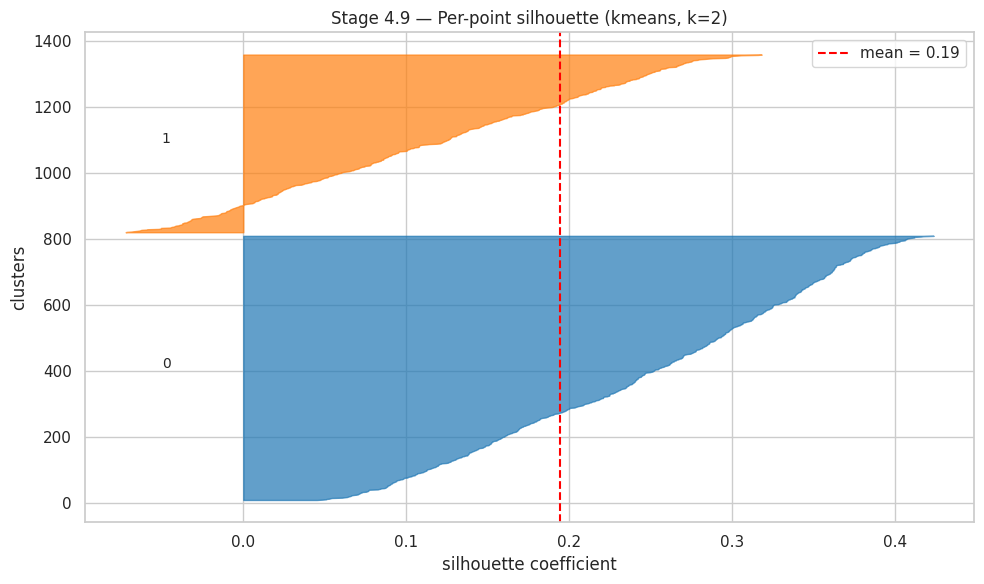

In [39]:
sil_vals = silhouette_samples(X_pca, final_labels)
mean_sil = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
palette = sns.color_palette("tab10", n_colors=K_CHOSEN)
for c in range(K_CHOSEN):
    vals = np.sort(sil_vals[final_labels == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=palette[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(c), fontsize=10)
    y_lower = y_upper + 10
ax.axvline(mean_sil, color="red", linestyle="--", label=f"mean = {mean_sil:.2f}")
ax.set_xlabel("silhouette coefficient"); ax.set_ylabel("clusters")
ax.set_title(f"Stage 4.9 — Per-point silhouette ({ALGO}, k={K_CHOSEN})")
ax.legend()
plt.tight_layout()
show_and_track(fig, "stage4_silhouette_per_point.png")
plt.show()

### 4.10 — UMAP 2-D scatter — cluster + season pair

**【目標 What?】** Two panels: UMAP coloured by chosen cluster_id, then by season.

**【說明 How to implement?】** `umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)` on the scaled matrix.

**【解釋結果 Why? How to explain the result】** Topology should mirror PCA but reveal non-linear structure. Compare 2023 vs 2024 panels — do seasons split or share the manifold?

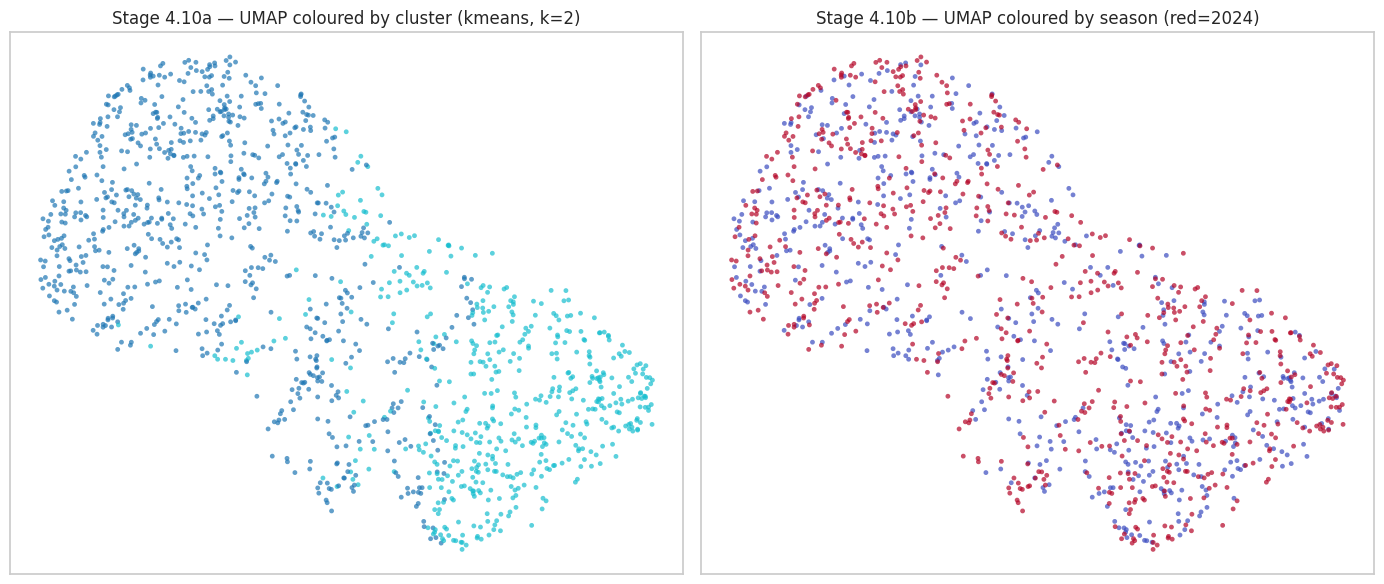

In [40]:
embed_um = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(embed_um[:, 0], embed_um[:, 1], c=final_labels, cmap="tab10",
                s=12, alpha=0.7, edgecolor="none")
axes[0].set_title(f"Stage 4.10a — UMAP coloured by cluster ({ALGO}, k={K_CHOSEN})")
season_int = team_game["season_tag"].astype("category").cat.codes.values
axes[1].scatter(embed_um[:, 0], embed_um[:, 1], c=season_int, cmap="coolwarm",
                s=12, alpha=0.7, edgecolor="none")
axes[1].set_title("Stage 4.10b — UMAP coloured by season (red=2024)")
for ax in axes: ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
show_and_track(fig, "stage4_umap_pair.png")
plt.show()

### 4.11 — t-SNE 2-D — perplexity sanity check

**【目標 What?】** Compute t-SNE at two perplexities and compare topology with UMAP.

**【說明 How to implement?】** `sklearn.manifold.TSNE` at perplexity 15 and 50.

**【解釋結果 Why? How to explain the result】** If t-SNE and UMAP agree on cluster locations, the structure is robust to projection choice. Disagreement ⇒ the clusters live in a higher-dimensional shape and 2-D views are projection-dependent.

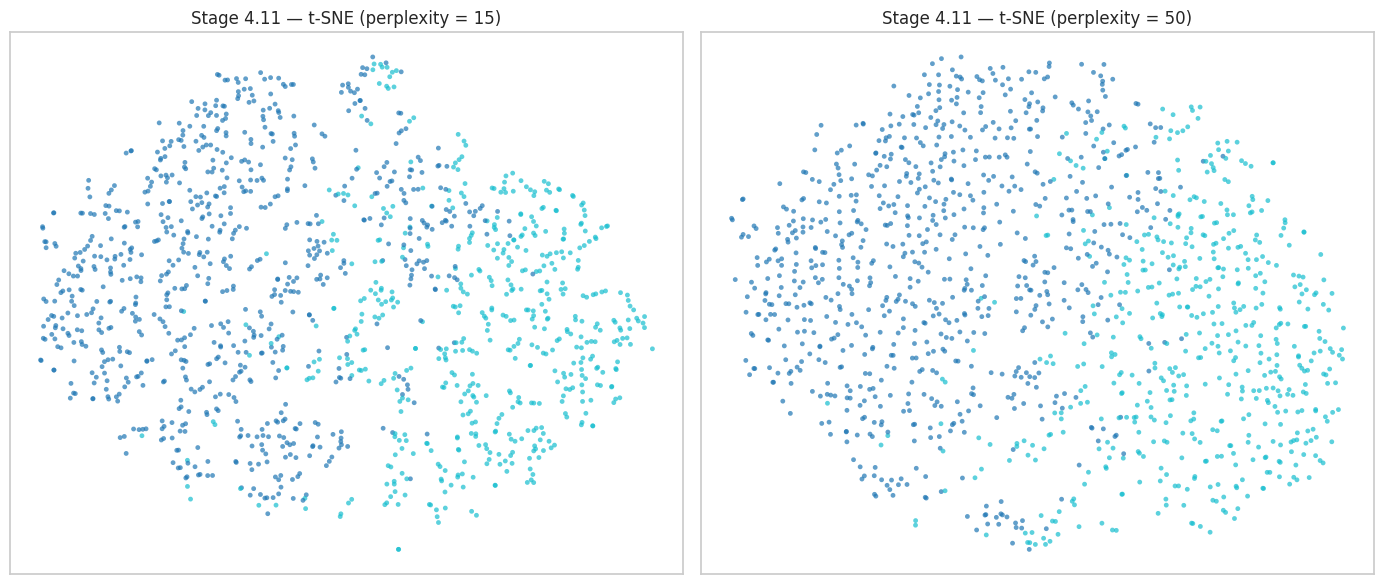

In [41]:
from sklearn.manifold import TSNE
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, perp in zip(axes, [15, 50]):
    emb = TSNE(n_components=2, perplexity=perp, random_state=RANDOM_STATE,
               init="pca", learning_rate="auto").fit_transform(X_pca)
    ax.scatter(emb[:, 0], emb[:, 1], c=final_labels, cmap="tab10",
               s=12, alpha=0.7, edgecolor="none")
    ax.set_title(f"Stage 4.11 — t-SNE (perplexity = {perp})")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
show_and_track(fig, "stage4_tsne_perplexity.png")
plt.show()

### 4.12 — Cluster mean ± SD table

**【目標 What?】** For each chosen cluster, compute mean ± SD of every (raw) feature.

**【說明 How to implement?】** `team_game.assign(cluster=final_labels).groupby('cluster')[NUMERIC_FEATURES].agg(['mean','std'])`.

**【解釋結果 Why? How to explain the result】** Easiest interpretation: which cluster has the highest `run_per_hit`, the lowest `whip_like`, etc.

In [42]:
tg_clustered = team_game.copy()
tg_clustered["cluster"] = final_labels
cmean = tg_clustered.groupby("cluster")[NUMERIC_FEATURES].mean().round(3)
cstd = tg_clustered.groupby("cluster")[NUMERIC_FEATURES].std().round(3)
show_and_track(cmean, "stage4_cluster_means.csv", "table")
show_and_track(cstd, "stage4_cluster_stds.csv", "table")
display(Markdown("**Cluster means**")); display(cmean)
display(Markdown("**Cluster std-dev**")); display(cstd)

**Cluster means**

,runs_scored,runs_allowed,run_diff,early_runs,middle_runs,late_runs,scored_first,led_after_3,led_after_6,AB,...,offense_pressure_score,outs_pitched,innings_pitched,hits_allowed,bb_allowed,hr_allowed,so_pitched,whip_like,strikeout_walk_ratio,run_prevention_score
cluster,,,,,,,,,,,,,,,,,,,,,
0,2.378,4.950,-2.572,0.603,0.856,0.866,0.263,0.154,0.154,32.753,...,2.846,26.180,8.727,9.404,3.275,0.596,6.111,1.464,2.725,-2.709
1,6.840,3.019,3.822,2.436,2.369,1.928,0.709,0.699,0.850,35.332,...,10.909,27.302,9.101,8.013,2.729,0.393,7.156,1.183,3.604,1.015


**Cluster std-dev**

,runs_scored,runs_allowed,run_diff,early_runs,middle_runs,late_runs,scored_first,led_after_3,led_after_6,AB,...,offense_pressure_score,outs_pitched,innings_pitched,hits_allowed,bb_allowed,hr_allowed,so_pitched,whip_like,strikeout_walk_ratio,run_prevention_score
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.772,3.305,3.232,0.929,1.188,1.194,0.441,0.361,0.361,3.157,...,3.404,2.197,0.732,3.485,1.961,0.807,2.623,0.505,2.367,5.662
1,2.811,2.454,3.071,2.006,2.191,2.079,0.455,0.459,0.358,4.210,...,4.596,1.736,0.579,3.210,1.858,0.635,2.814,0.434,2.609,4.634


### 4.13 — Cluster radar (parallel-coordinates alternative)

**【目標 What?】** Radar chart: each spoke is a Wang-top-10 feature; one polygon per cluster (z-scored mean).

**【說明 How to implement?】** Plot in matplotlib polar projection; lines fill with alpha.

**【解釋結果 Why? How to explain the result】** A cluster whose polygon bulges on offense features (H, AB, run_per_hit) and shrinks on pitching features is the 'slug-fest offense' archetype, etc.

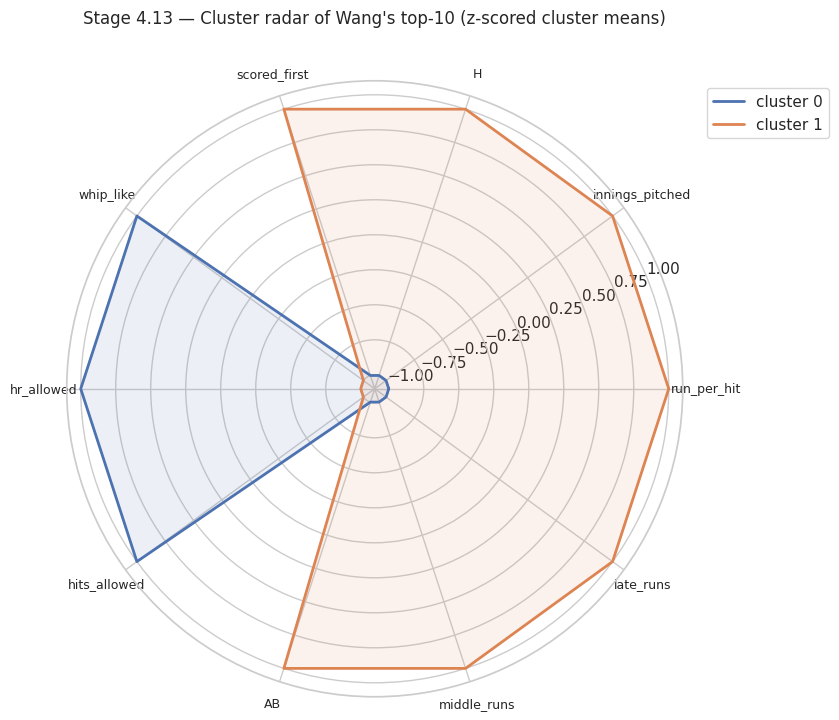

In [43]:
cm_z = (cmean[WANG_TOP10] - cmean[WANG_TOP10].mean()) / cmean[WANG_TOP10].std(ddof=0).replace(0, 1)
angles = np.linspace(0, 2 * np.pi, len(WANG_TOP10), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in cm_z.index:
    vals = cm_z.loc[c].tolist() + [cm_z.loc[c].tolist()[0]]
    ax.plot(angles, vals, label=f"cluster {c}", lw=2)
    ax.fill(angles, vals, alpha=0.10)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(WANG_TOP10, fontsize=9)
ax.set_title(f"Stage 4.13 — Cluster radar of Wang's top-10 (z-scored cluster means)", y=1.08)
ax.legend(bbox_to_anchor=(1.25, 1.0))
show_and_track(fig, "stage4_cluster_radar.png")
plt.show()

### 4.14 — Per-cluster feature boxplot grid

**【目標 What?】** Box+strip plot per Wang-top-10 feature, x = cluster.

**【說明 How to implement?】** `sns.boxplot` faceted in a 2×5 grid.

**【解釋結果 Why? How to explain the result】** Tall boxes ⇒ feature carries different mass per cluster ⇒ that feature defines the cluster.

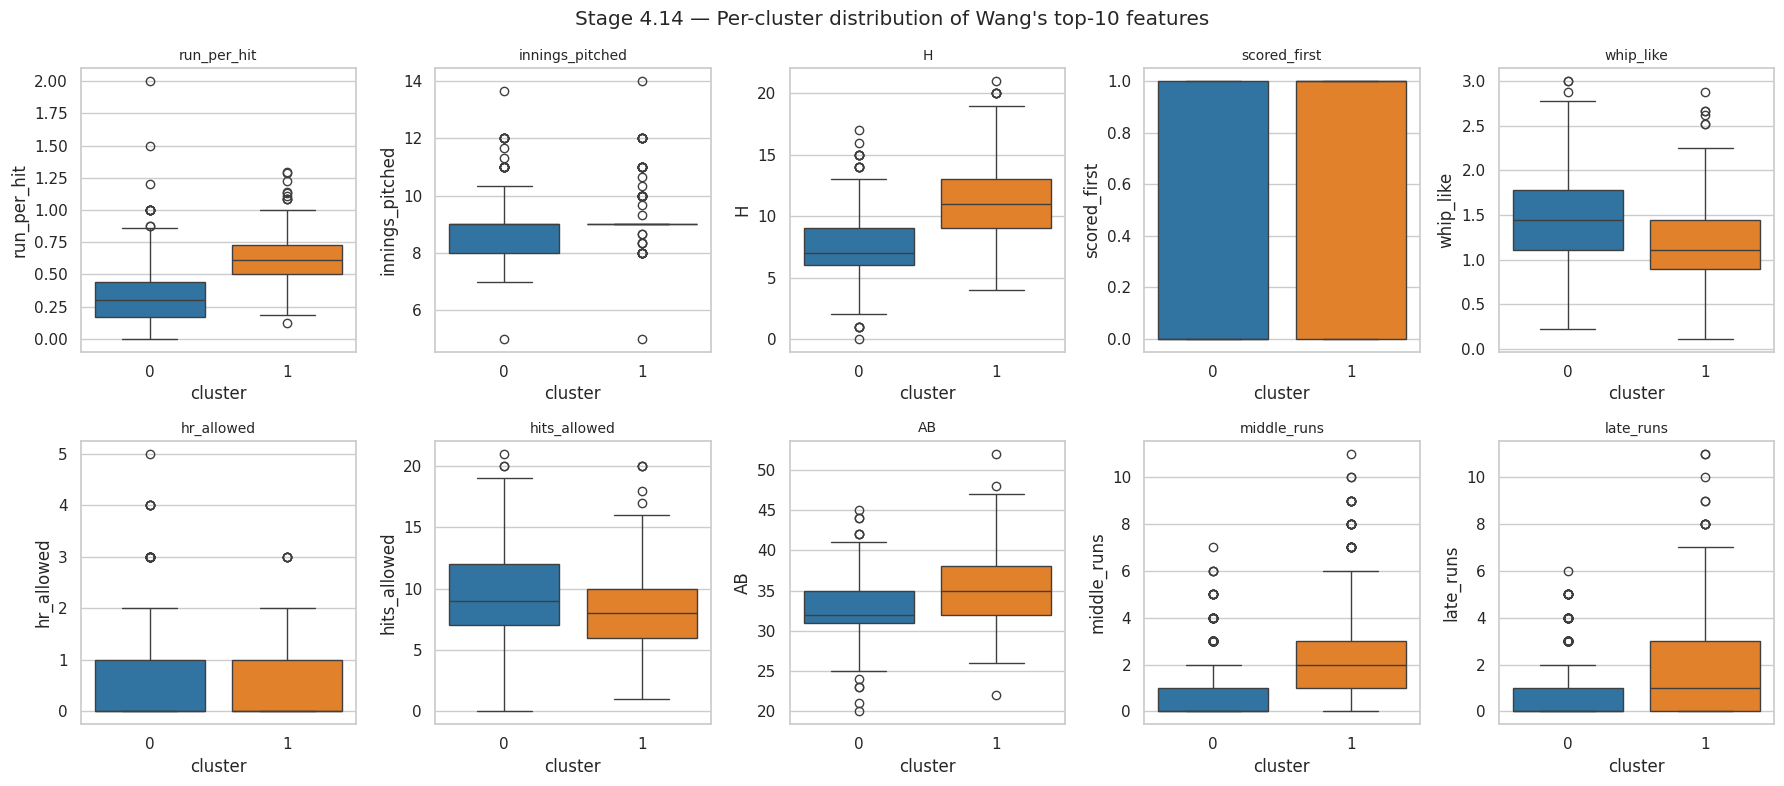

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, feat in zip(axes.flat, WANG_TOP10):
    sns.boxplot(data=tg_clustered, x="cluster", y=feat, ax=ax, palette="tab10")
    ax.set_title(feat, fontsize=10)
fig.suptitle("Stage 4.14 — Per-cluster distribution of Wang's top-10 features")
plt.tight_layout()
show_and_track(fig, "stage4_cluster_boxplots.png")
plt.show()

### 4.15 — Surrogate classifier + Tree-SHAP for cluster labels

**【目標 What?】** Train a one-vs-rest RandomForest to predict cluster from features; explain with SHAP TreeExplainer.

**【說明 How to implement?】** Per cluster: target = 1 if cluster==c else 0; explain on a sample of 200 rows; rank features by |SHAP|. Generate a human-readable label from top-3 SHAP features.

**【解釋結果 Why? How to explain the result】** If cluster 0's top SHAPs are run_per_hit↑ and whip_like↓, label = 'firepower duel'. This grounds the cluster names in baseball semantics.

In [45]:
from sklearn.ensemble import RandomForestClassifier

shap_ranks = {}
for c in sorted(set(final_labels)):
    if c < 0: continue
    y = (final_labels == c).astype(int)
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                n_jobs=-1).fit(X_scaled, y)
    sample = X_scaled.sample(min(200, len(X_scaled)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(rf)
    sv = explainer.shap_values(sample)
    if isinstance(sv, list):
        sv = sv[-1]  # positive class
    if hasattr(sv, "values"):
        sv = sv.values
    if sv.ndim == 3:
        sv = sv[..., 1]  # newer shap returns (n_samples, n_features, n_classes)
    mean_abs = pd.Series(np.abs(sv).mean(axis=0),
                         index=X_scaled.columns).sort_values(ascending=False)
    shap_ranks[c] = mean_abs.head(5)

shap_table = pd.concat({f"cluster {c}": s for c, s in shap_ranks.items()}, axis=1).round(3)
show_and_track(shap_table, "stage4_shap_per_cluster.csv", "table")
display(shap_table)

def auto_label(row, top_feats):
    bits = []
    means = cmean.loc[row][top_feats.index]
    grand = cmean.mean()[top_feats.index]
    for f in top_feats.index[:2]:
        sign = "↑" if means[f] > grand[f] else "↓"
        bits.append(f"{f}{sign}")
    return " · ".join(bits)

cluster_names = {c: auto_label(c, s) for c, s in shap_ranks.items()}
print("\nAuto-generated cluster labels (top-2 |SHAP| direction):")
for c, name in cluster_names.items():
    print(f"  cluster {c}: {name}")

,cluster 0,cluster 1
run_diff,0.095,0.095
offense_pressure_score,0.094,0.094
led_after_6,0.082,0.082
runs_scored,0.062,0.062
led_after_3,0.041,0.041



Auto-generated cluster labels (top-2 |SHAP| direction):
  cluster 0: run_diff↓ · offense_pressure_score↓
  cluster 1: run_diff↑ · offense_pressure_score↑


### 4.16 — 2023 vs 2024 cluster-frequency shift

**【目標 What?】** Grouped bar: count of team-games per cluster per season; plus a Sankey of season→cluster flow.

**【說明 How to implement?】** Crosstab on (season_tag, cluster) → bar; plotly `go.Sankey` for the flow.

**【解釋結果 Why? How to explain the result】** A cluster appearing much more often in 2024 quantifies the meta change. Zero-flow gaps in the Sankey highlight stable archetypes.

cluster,0,1
season_tag,,
2023,371,249
2024,430,290


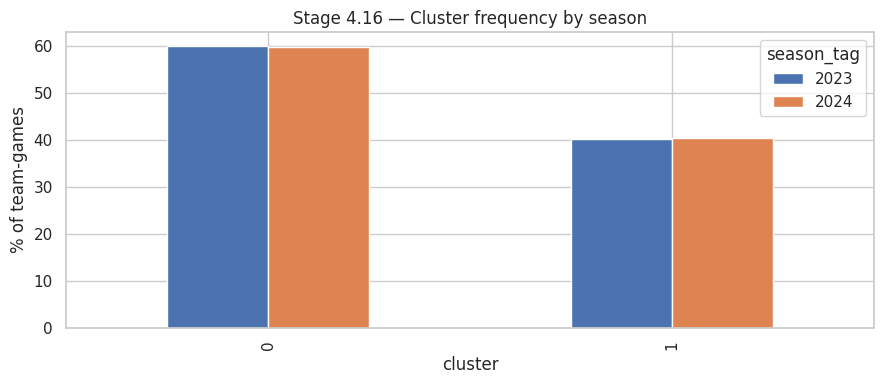

In [46]:
ctab = pd.crosstab(tg_clustered["season_tag"], tg_clustered["cluster"])
show_and_track(ctab, "stage4_season_cluster_xtab.csv", "table")
display(ctab)

fig, ax = plt.subplots(figsize=(9, 4))
ctab_pct = ctab.div(ctab.sum(axis=1), axis=0) * 100
ctab_pct.T.plot(kind="bar", ax=ax)
ax.set_ylabel("% of team-games"); ax.set_title("Stage 4.16 — Cluster frequency by season")
plt.tight_layout()
show_and_track(fig, "stage4_cluster_freq_shift.png")
plt.show()

import plotly.graph_objects as go
labels_sk = [f"{s}" for s in ctab.index] + [f"cluster {c}" for c in ctab.columns]
src, tgt, val = [], [], []
for i, s in enumerate(ctab.index):
    for j, c in enumerate(ctab.columns):
        src.append(i); tgt.append(len(ctab.index) + j); val.append(int(ctab.loc[s, c]))
sk = go.Figure(go.Sankey(node=dict(label=labels_sk, pad=15, thickness=15),
                          link=dict(source=src, target=tgt, value=val)))
sk.update_layout(title_text="Stage 4.16 — Sankey: season → cluster", font_size=10)
show_and_track(sk, "stage4_season_cluster_sankey.html")
sk.show()

### 4.17 — Discovered-feature register

**【目標 What?】** Add the unsupervised columns to the working dataframe: `cluster_id`, GMM soft probabilities, top PC scores.

**【說明 How to implement?】** Append `cluster_id` (chosen algo), `pc1…pc{K_PCA}`, and (if GMM passed) per-cluster prob columns.

**【解釋結果 Why? How to explain the result】** These are the *new features* the unsupervised stage proposes — Stage 5 cross-references them with Wang's list.

In [47]:
tg_with_new = team_game.copy()
tg_with_new["cluster_id"] = final_labels
for i in range(K_PCA):
    tg_with_new[f"pc{i+1}"] = X_pca.iloc[:, i].values

gmm = GaussianMixture(n_components=K_GMM, covariance_type="diag",
                      n_init=3, random_state=RANDOM_STATE).fit(X_pca)
probs = gmm.predict_proba(X_pca)
for i in range(K_GMM):
    tg_with_new[f"gmm_p{i}"] = probs[:, i]

print("Added columns:", ["cluster_id"] + [f"pc{i+1}" for i in range(K_PCA)] +
      [f"gmm_p{i}" for i in range(K_GMM)])
display(tg_with_new[["team","season_tag","cluster_id"] +
                    [f"pc{i+1}" for i in range(min(3, K_PCA))]].head())

Added columns: ['cluster_id', 'pc1', 'pc2', 'pc3', 'pc4', 'pc5', 'pc6', 'pc7', 'pc8', 'pc9', 'pc10', 'pc11', 'pc12', 'pc13', 'gmm_p0', 'gmm_p1', 'gmm_p2', 'gmm_p3', 'gmm_p4', 'gmm_p5', 'gmm_p6', 'gmm_p7', 'gmm_p8']


,team,season_tag,cluster_id,pc1,pc2,pc3
0,樂天桃猿,2023,0,0.083690,-0.964706,-1.715692
1,中信兄弟,2023,0,-1.874347,-1.157077,2.238258
2,中信兄弟,2023,0,-0.758132,-0.958902,-0.691998
3,味全龍,2023,0,-0.643478,-0.972019,2.057350
4,富邦悍將,2023,1,2.850111,2.248717,-1.889511


## Stage 5 — Synthesis

### 5.1 — Overlap: unsupervised-discovered features ↔ Wang's top-10

**【目標 What?】** For each Wang feature, list its rank in PC1 |loading|, PC2 |loading|, and its highest SHAP-importance across the auto-named clusters.

**【說明 How to implement?】** Stitch loadings_abs and shap_table together; sort by combined score.

**【解釋結果 Why? How to explain the result】** Features that score high in BOTH unsupervised loadings AND surrogate SHAP are doubly confirmed; those low in both are candidates to drop from future supervised work.

In [48]:
overlap_rows = []
shap_max = pd.DataFrame(shap_ranks).fillna(0).max(axis=1)
for f in WANG_TOP10:
    overlap_rows.append({
        "feature": f,
        "pc1_loading": float(loadings_abs.loc[f, "PC1"]) if f in loadings_abs.index else np.nan,
        "pc2_loading": float(loadings_abs.loc[f, "PC2"]) if f in loadings_abs.index else np.nan,
        "max_shap_per_cluster": float(shap_max.get(f, np.nan)),
        "in_kept_set": f in KEPT,
    })
overlap = pd.DataFrame(overlap_rows).round(3)
overlap["combined_score"] = overlap[["pc1_loading","pc2_loading","max_shap_per_cluster"]].sum(axis=1).round(3)
overlap = overlap.sort_values("combined_score", ascending=False)
show_and_track(overlap, "stage5_wang_overlap.csv", "table")
display(overlap)

,feature,pc1_loading,pc2_loading,max_shap_per_cluster,in_kept_set,combined_score
2,H,0.737,0.354,NaN,True,1.091
6,hits_allowed,0.199,0.754,NaN,True,0.953
7,AB,0.513,0.417,NaN,True,0.930
4,whip_like,0.219,0.630,NaN,True,0.849
3,scored_first,0.474,0.299,NaN,True,0.773
9,late_runs,0.451,0.268,NaN,True,0.719
8,middle_runs,0.519,0.174,NaN,True,0.693
0,run_per_hit,0.486,0.104,NaN,True,0.590
5,hr_allowed,0.146,0.391,NaN,True,0.537
1,innings_pitched,NaN,NaN,NaN,False,0.000


### 5.2 — New candidate features proposed by the unsupervised stage

**【目標 What?】** Enumerate features the unsupervised stage adds: cluster_id, top GMM soft-probs, top PC scores.

**【說明 How to implement?】** List each new feature's interpretation (from cluster names & loadings narrative).

**【解釋結果 Why? How to explain the result】** These can be fed into a future supervised model and benchmarked against Wang's baseline.

In [49]:
candidates = [
    {"new_feature": "cluster_id", "kind": "categorical",
     "description": "Final hard cluster assignment ({} clusters via {})".format(K_CHOSEN, ALGO),
     "interpretation": "; ".join(f"{c}: {n}" for c, n in cluster_names.items())},
]
for i in range(K_GMM):
    candidates.append({
        "new_feature": f"gmm_p{i}",
        "kind": "soft probability",
        "description": f"Posterior probability of GMM component {i}",
        "interpretation": "smooth membership; useful as regression covariate",
    })
for i in range(min(3, K_PCA)):
    top_feats = loadings_abs.iloc[:, i].abs().nlargest(3).index.tolist()
    candidates.append({
        "new_feature": f"pc{i+1}",
        "kind": "continuous PC score",
        "description": f"Projection onto PC{i+1} ({pca_k.explained_variance_ratio_[i]:.1%} variance)",
        "interpretation": f"loaded by {top_feats}",
    })

new_feat = pd.DataFrame(candidates)
show_and_track(new_feat, "stage5_new_candidate_features.csv", "table")
display(new_feat)

,new_feature,kind,description,interpretation
0,cluster_id,categorical,Final hard cluster assignment (2 clusters via ...,0: run_diff↓ · offense_pressure_score↓; 1: run...
1,gmm_p0,soft probability,Posterior probability of GMM component 0,smooth membership; useful as regression covariate
2,gmm_p1,soft probability,Posterior probability of GMM component 1,smooth membership; useful as regression covariate
3,gmm_p2,soft probability,Posterior probability of GMM component 2,smooth membership; useful as regression covariate
4,gmm_p3,soft probability,Posterior probability of GMM component 3,smooth membership; useful as regression covariate
5,gmm_p4,soft probability,Posterior probability of GMM component 4,smooth membership; useful as regression covariate
6,gmm_p5,soft probability,Posterior probability of GMM component 5,smooth membership; useful as regression covariate
7,gmm_p6,soft probability,Posterior probability of GMM component 6,smooth membership; useful as regression covariate
8,gmm_p7,soft probability,Posterior probability of GMM component 7,smooth membership; useful as regression covariate
9,gmm_p8,soft probability,Posterior probability of GMM component 8,smooth membership; useful as regression covariate


### 5.3 — Caveats (no code)

* This notebook stops at **unsupervised feature discovery** by design — no supervised
  benchmark of the new features against `win` is included. Doing so would compare the
  unsupervised feature register against Wang's 93.2% F1 baseline.
* Sample size is small (~1,200 team-game rows). HDBSCAN noise + few clusters is
  expected. Stronger conclusions need multi-season data.
* PCA loadings interpret *linear* combinations; non-linear structure surfaces only in
  UMAP/t-SNE / GMM — keep both perspectives in mind.
* Bootstrap-Jaccard with B=50 is fast but noisy. For a final report use B=500.

## Stage 6 — Export switch (the final cell)

### 6.1 — Registry preview

**【目標 What?】** Print the full ARTIFACTS registry as a table (name + kind only); no files written.

**【說明 How to implement?】** Pandas DataFrame view of the registry; index = position in `ARTIFACTS`.

**【解釋結果 Why? How to explain the result】** Use this to confirm everything you'd expect to export is in the list before flipping the flag.

In [50]:
registry = pd.DataFrame([{"idx": i, "name": a["name"], "kind": a["kind"]}
                         for i, a in enumerate(ARTIFACTS)])
print(f"Artifacts tracked: {len(registry)}")
display(registry)

Artifacts tracked: 43


,idx,name,kind
0,0,stage2_describe_overall.csv,table
1,1,stage2_per_season_wang10.csv,table
2,2,stage2_base_rates.csv,table
3,3,stage2_corr_vs_win.csv,table
4,4,stage2_corr_vs_run_diff.csv,table
5,5,stage2_skew_kurtosis_missing.csv,table
6,6,stage3_small_multiples_top10.png,figure
7,7,stage3_spearman_heatmap.png,figure
8,8,stage3_pairplot_top5.png,figure
9,9,stage3_home_away_means.png,figure


### 6.2 — One-click export switch

**【目標 What?】** If `DOWNLOAD_ALL` is True, write every tracked artifact to disk, zip them, and display a Jupyter `FileLink`. Otherwise, do nothing on disk.

**【說明 How to implement?】** Walk `ARTIFACTS`; for figures call `.savefig` (matplotlib) or `.write_html` (plotly); for tables call `.to_csv`. Then `shutil.make_archive`.

**【解釋結果 Why? How to explain the result】** Default `DOWNLOAD_ALL = False` ⇒ no side effects. To export everything, set `DOWNLOAD_ALL = True` at the TOP of this cell and re-run only this cell.

In [51]:
# Flip to True (this line only) and re-run to export everything as a single zip.
DOWNLOAD_ALL = False

if not DOWNLOAD_ALL:
    print("DOWNLOAD_ALL is False → nothing written.")
    print("Set DOWNLOAD_ALL = True in this cell and re-execute to export all artifacts.")
else:
    out_dir = Path("/tmp/cpbl_artifacts"); out_dir.mkdir(exist_ok=True)
    for art in ARTIFACTS:
        name = art["name"]; kind = art["kind"]; payload = art["payload"]
        dest = out_dir / name
        try:
            if kind == "table":
                payload.to_csv(dest, index=True, encoding="utf-8-sig")
            elif kind == "figure":
                if hasattr(payload, "savefig"):
                    payload.savefig(dest, bbox_inches="tight")
                elif name.endswith(".html") and hasattr(payload, "write_html"):
                    payload.write_html(dest)
                else:
                    print(f"  skip unknown figure type for {name}")
                    continue
            else:
                print(f"  skip unknown kind {kind} for {name}")
                continue
            print(f"  wrote {dest}")
        except Exception as e:
            print(f"  FAILED {name}: {e}")

    zip_base = "/tmp/cpbl_artifacts"
    archive = shutil.make_archive(zip_base, "zip", out_dir)
    print(f"\n✓ Bundle: {archive} ({Path(archive).stat().st_size/1024:.1f} KB)")
    display(FileLink(archive))

DOWNLOAD_ALL is False → nothing written.
Set DOWNLOAD_ALL = True in this cell and re-execute to export all artifacts.
